<img src="Figures\Logos\Institutions.png" width="800px">

# Supplementary 1
Author code: Jorge Lizarazo

This notebook assembles nest and egg measurements for Myioborus warblers and evaluates how those traits vary with species identity and elevation. The workflow moves from whole-nest structure to layer-specific components and then to egg number, egg shape, egg volume, and egg mass, keeping nest-level and egg-level analyses separate where that distinction matters. Most nest traits are analysed with generalized linear models using distributional assumptions suited to strictly positive or count data, while egg-level responses are explored with the same emphasis on transparent model specification and interpretable effect sizes. Taken together, these sections test whether elevational and taxonomic differences in nest construction are broad across the nest or concentrated in specific structural or reproductive traits.

Pipeline:

1. Import the curated nest dataset and harmonise station names and core categorical fields.
2. Build nest-level tables for traits that should be counted once per nest.
3. Fit generalized linear models for total nest mass and compare alternative formulations.
4. Repeat the same logic for outer-layer mass and other layer-specific nest components.
5. Evaluate nest placement and clutch-size responses at the nest level.
6. Examine egg length, width, elongation, and volume across species and elevation.
7. Summarise egg-mass patterns and related pairwise comparisons.
8. Retain figures, model summaries, and short narrative notes alongside each analysis block.

In [58]:
import pandas as pd
import numpy as np
import re
import statsmodels.formula.api as smf
import statsmodels.api as sm

from itertools import combinations
from scipy import stats
from statsmodels.stats.multitest import multipletests
from patsy import build_design_matrices
import matplotlib.pyplot as plt


In [59]:


# File path
file_path = r"D:\Myiborus\Myiborus_nests\data\Datos_Nidos_SGG.csv"

# Load CSV
myi = pd.read_csv(file_path)

In [60]:
myi

,Estacion,Numero_Libreta,Pagina,Año,Familia,Especie,ID_del_Nido,N,S,W,...,nota comportamental. Observacion en campo.,Nota 1,eclosion,nota,puesta,periodo huevos,periodo pollos,t.huevos(dias),t.pollos(dias),nota.1
0,Road_San_Pedro,1,29,2009,Parulidae,Myioborus_melanocephalus,01_SPR09,NaN,13.1015,71.5657,...,NaN,-,-,-,-,-,-,-,-,-
1,Road_San_Pedro,1,29,2009,Parulidae,Myioborus_melanocephalus,01_SPR09,NaN,13.1015,71.5657,...,NaN,-,-,-,-,-,-,-,-,-
2,Road_San_Pedro,1,63,2009,Parulidae,Myioborus_miniatus,01_SPR09a,NaN,"13°05´47,6""","71°33´50,6""",...,NaN,-,-,-,-,-,-,-,-,-
3,Road_San_Pedro,1,63,2009,Parulidae,Myioborus_miniatus,01_SPR09a,NaN,"13°05´47,6""","71°33´50,6""",...,NaN,-,-,-,-,-,-,-,-,-
4,Road_San_Pedro,1,63,2009,Parulidae,Myioborus_miniatus,01_SPR09a,NaN,"13°05´47,6""","71°33´50,6""",...,NaN,-,-,-,-,-,-,-,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802,Wayquecha,5,63,2010,Parulidae,Myioborus_melanocephalus,W4_CJS10,NaN,"13°10´22""","71°35´31,1""",...,NaN,-,-,-,-,-,-,-,-,-
803,Wayquecha,7,14,2011,Parulidae,Myioborus_melanocephalus,W6_AOQ11,NaN,13.1776,71.6047,...,NaN,-,-,-,-,-,-,-,-,-
804,Wayquecha,7,14,2011,Parulidae,Myioborus_melanocephalus,W6_AOQ11,NaN,13.1776,71.6047,...,NaN,-,-,-,-,-,-,-,-,-
805,Wayquecha,7,14,2011,Parulidae,Myioborus_melanocephalus,W6_AOQ11,NaN,13.1776,71.6047,...,NaN,-,-,-,-,-,-,-,-,-


In [61]:
print("Dataset shape:", myi.shape)
print("\nColumn names:")
print(myi.columns.tolist())

print("\nFirst rows:")
display(myi.head())

print("\nData types:")
print(myi.dtypes)

Dataset shape: (807, 91)

Column names:
['Estacion', 'Numero_Libreta', 'Pagina', 'Año', 'Familia', 'Especie', 'ID_del_Nido', 'N', 'S', 'W', 'Elevacion', 'Fecha_de_encuentro', 'FENOLOGIA', 'Fecha _eclosion', 'Ultima_fecha_de_actividad', 'Fecha_de_inactividad (Last day nest was checked)', 'Dias_Totales', 'Estado', 'Notas', 'nota sitio', 'Huevo_o_Polluelo', 'Tipo_de_nido', 'Nido_Int_Largo_mm', 'Nido_Int_Ancho_mm', 'Nido_Int_Espesor_mm', 'Nido_Int_Profundidad_1_mm', 'Nido_Int_Profundidad_2_mm', 'Nido_Ext_Largo_mm', 'Nido_Ext_Ancho_mm', 'Nido_Ext_Alto_mm', 'Altura_sobre_el_suelo_cm', 'Nido_peso_Total_g', 'Capa_1_g', 'Capa_2_g', 'Capa_3_g', 'Capa_4_g', 'Material_extra_g', 'descripcion materiales', 'ID_del_Huevo', 'Desarrollo huevos', 'Huevo_Largo_mm', 'Huevo_Ancho_mm', 'Huevo_Peso_g', 'Medianas y desviacion 95%', 'Numero_de_Huevos', 'nota huevos', 'Fecha_de_medición', 'ID_del_Polluelo', 'Individuo', 'Polluelo_Edad_dias (n+#) siendo n los dias desde eclosion, y # dias de segiumiento ', 'huevo

,Estacion,Numero_Libreta,Pagina,Año,Familia,Especie,ID_del_Nido,N,S,W,...,nota comportamental. Observacion en campo.,Nota 1,eclosion,nota,puesta,periodo huevos,periodo pollos,t.huevos(dias),t.pollos(dias),nota.1
0,Road_San_Pedro,1,29,2009,Parulidae,Myioborus_melanocephalus,01_SPR09,NaN,13.1015,71.5657,...,NaN,-,-,-,-,-,-,-,-,-
1,Road_San_Pedro,1,29,2009,Parulidae,Myioborus_melanocephalus,01_SPR09,NaN,13.1015,71.5657,...,NaN,-,-,-,-,-,-,-,-,-
2,Road_San_Pedro,1,63,2009,Parulidae,Myioborus_miniatus,01_SPR09a,NaN,"13°05´47,6""","71°33´50,6""",...,NaN,-,-,-,-,-,-,-,-,-
3,Road_San_Pedro,1,63,2009,Parulidae,Myioborus_miniatus,01_SPR09a,NaN,"13°05´47,6""","71°33´50,6""",...,NaN,-,-,-,-,-,-,-,-,-
4,Road_San_Pedro,1,63,2009,Parulidae,Myioborus_miniatus,01_SPR09a,NaN,"13°05´47,6""","71°33´50,6""",...,NaN,-,-,-,-,-,-,-,-,-



Data types:
Estacion          object
Numero_Libreta    object
Pagina            object
Año                int64
Familia           object
                   ...  
periodo huevos    object
periodo pollos    object
t.huevos(dias)    object
t.pollos(dias)    object
nota.1            object
Length: 91, dtype: object


In [62]:
myi['Estacion'] = myi['Estacion'].replace({
    'Road_San_Pedro': 'San_Pedro'
})

In [63]:
print("Number of raw Estacion values:", myi['Estacion'].nunique(dropna=False))

station_counts = (
    myi['Estacion']
    .value_counts(dropna=False)
    .reset_index()
)

station_counts.columns = ['Estacion', 'n']
display(station_counts)

Number of raw Estacion values: 6


,Estacion,n
0,Tatama,353
1,San_Pedro,174
2,Chicoral,98
3,Zygia,78
4,Danubio,72
5,Wayquecha,32


In [64]:
# Columns to keep
cols_keep = [
    'Estacion',                    # Field station or study site where the nest was recorded.
    'Especie',                     # Bird species associated with the nest record.
    'ID_del_Nido',                 # Unique identifier assigned to each nest.
    'N',                           # North coordinate.
    'S',                           # South coordinate.
    'W',                           # West coordinate.
    'Elevacion',                   # Elevation of the nest location above sea level.
    'Fecha_de_encuentro',          # Date when the nest was first found.
    'Huevo_o_Polluelo',            # Nest stage at discovery, indicating whether eggs or nestlings were present.
    'Nido_Int_Largo_mm',           # Internal nest length measured in millimetres.
    'Nido_Int_Ancho_mm',           # Internal nest width measured in millimetres.
    'Nido_Int_Espesor_mm',         # Internal nest wall thickness measured in millimetres.
    'Nido_Int_Profundidad_1_mm',   # First internal nest depth measurement in millimetres.
    'Nido_Int_Profundidad_2_mm',   # Second internal nest depth measurement in millimetres.
    'Nido_Ext_Largo_mm',           # External nest length measured in millimetres.
    'Nido_Ext_Ancho_mm',           # External nest width measured in millimetres.
    'Nido_Ext_Alto_mm',            # External nest height measured in millimetres.
    'Altura_sobre_el_suelo_cm',    # Height of the nest above the ground, measured in centimetres.
    'Nido_peso_Total_g',           # Total nest mass measured in grams.
    'Capa_1_g',                    # Mass of nest material layer 1 measured in grams.
    'Capa_2_g',                    # Mass of nest material layer 2 measured in grams.
    'Capa_3_g',                    # Mass of nest material layer 3 measured in grams.
    'Capa_4_g',                    # Mass of nest material layer 4 measured in grams.
    'ID_del_Huevo',                # Unique identifier assigned to each egg.
    'Huevo_Largo_mm',              # Egg length measured in millimetres.
    'Huevo_Ancho_mm',              # Egg width measured in millimetres.
    'Huevo_Peso_g',                # Egg mass measured in grams.
    'Numero_de_Huevos',            # Total number of eggs recorded in the nest.
]

In [65]:
missing_cols = [col for col in cols_keep if col not in myi.columns]

if missing_cols:
    print("These columns are missing or have different names:")
    print(missing_cols)
    print("\nAvailable columns:")
    print(myi.columns.tolist())
else:
    myi = myi[cols_keep].copy()

    print("Filtered dataset shape:", myi.shape)
    print("\nColumn names:")
    print(myi.columns.tolist())

    display(myi.head())

    print("\nData types:")
    print(myi.dtypes)

Filtered dataset shape: (807, 28)

Column names:
['Estacion', 'Especie', 'ID_del_Nido', 'N', 'S', 'W', 'Elevacion', 'Fecha_de_encuentro', 'Huevo_o_Polluelo', 'Nido_Int_Largo_mm', 'Nido_Int_Ancho_mm', 'Nido_Int_Espesor_mm', 'Nido_Int_Profundidad_1_mm', 'Nido_Int_Profundidad_2_mm', 'Nido_Ext_Largo_mm', 'Nido_Ext_Ancho_mm', 'Nido_Ext_Alto_mm', 'Altura_sobre_el_suelo_cm', 'Nido_peso_Total_g', 'Capa_1_g', 'Capa_2_g', 'Capa_3_g', 'Capa_4_g', 'ID_del_Huevo', 'Huevo_Largo_mm', 'Huevo_Ancho_mm', 'Huevo_Peso_g', 'Numero_de_Huevos']


,Estacion,Especie,ID_del_Nido,N,S,W,Elevacion,Fecha_de_encuentro,Huevo_o_Polluelo,Nido_Int_Largo_mm,...,Nido_peso_Total_g,Capa_1_g,Capa_2_g,Capa_3_g,Capa_4_g,ID_del_Huevo,Huevo_Largo_mm,Huevo_Ancho_mm,Huevo_Peso_g,Numero_de_Huevos
0,San_Pedro,Myioborus_melanocephalus,01_SPR09,NaN,13.1015,71.5657,1949.0,26-Aug-09,Huevo,NaN,...,NaN,NaN,NaN,NaN,NaN,1A,16.9,12.5,1.50,2.0
1,San_Pedro,Myioborus_melanocephalus,01_SPR09,NaN,13.1015,71.5657,1949.0,26-Aug-09,Huevo,NaN,...,NaN,NaN,NaN,NaN,NaN,2B,16.9,12.8,1.60,2.0
2,San_Pedro,Myioborus_miniatus,01_SPR09a,NaN,"13°05´47,6""","71°33´50,6""",1938.0,02-Oct-09,Huevo,NaN,...,14.45,7.4,7.04,NaN,NaN,1A,17.2,13.2,1.55,3.0
3,San_Pedro,Myioborus_miniatus,01_SPR09a,NaN,"13°05´47,6""","71°33´50,6""",1938.0,02-Oct-09,Huevo,NaN,...,14.45,7.4,7.04,NaN,NaN,2B,18.0,13.0,1.65,3.0
4,San_Pedro,Myioborus_miniatus,01_SPR09a,NaN,"13°05´47,6""","71°33´50,6""",1938.0,02-Oct-09,Huevo,NaN,...,14.45,7.4,7.04,NaN,NaN,3C,16.9,13.0,1.50,3.0



Data types:
Estacion                      object
Especie                       object
ID_del_Nido                   object
N                             object
S                             object
W                             object
Elevacion                    float64
Fecha_de_encuentro            object
Huevo_o_Polluelo              object
Nido_Int_Largo_mm            float64
Nido_Int_Ancho_mm            float64
Nido_Int_Espesor_mm          float64
Nido_Int_Profundidad_1_mm    float64
Nido_Int_Profundidad_2_mm    float64
Nido_Ext_Largo_mm            float64
Nido_Ext_Ancho_mm            float64
Nido_Ext_Alto_mm             float64
Altura_sobre_el_suelo_cm     float64
Nido_peso_Total_g             object
Capa_1_g                      object
Capa_2_g                      object
Capa_3_g                      object
Capa_4_g                      object
ID_del_Huevo                  object
Huevo_Largo_mm               float64
Huevo_Ancho_mm               float64
Huevo_Peso_g             

In [66]:
myi['Especie'].value_counts(dropna=False)

Especie
Myioborus_miniatus          751
Myioborus_melanocephalus     41
Myioborus_ornatus            13
Myioborus_sp.                 2
Name: count, dtype: int64

In [67]:
myi = myi[myi['Especie'] != 'Myioborus_sp.'].copy()

print("New dataset shape:", myi.shape)
print(myi['Especie'].value_counts(dropna=False))

New dataset shape: (805, 28)
Especie
Myioborus_miniatus          751
Myioborus_melanocephalus     41
Myioborus_ornatus            13
Name: count, dtype: int64


In [68]:
def parse_coordinate(value):
    """
    Converts messy coordinate strings to decimal degrees.

    Handles examples like:
    - 13.1015
    - 13,05976°
    - 13°05´47,6"
    - 13°3.333
    - 3 33,986
    - 76,5816 no en libreta este dato

    Returns:
    - decimal coordinate as positive value
    - detected format
    - warning message if something looks suspicious
    """

    if pd.isna(value):
        return np.nan, "missing", None

    raw = str(value).strip()

    if raw.upper() in ["NA", "NAN", "NONE", ""]:
        return np.nan, "missing", None

    # Standardise text
    s = raw.replace(",", ".")
    s = s.replace("´", "'").replace("`", "'").replace("¨", "'")
    s = s.replace("º", "°")

    # Extract numbers only
    nums = re.findall(r"\d+(?:\.\d+)?", s)

    if len(nums) == 0:
        return np.nan, "unreadable", f"Could not extract numbers from: {raw}"

    nums = [float(x) for x in nums]

    warning = None

    # Case 1: one number only
    # Example: 13.1015 or 13,05976°
    if len(nums) == 1:
        val = nums[0]

        # Possible typo like 325,269 where latitude should be around 3 or 5
        if val > 90:
            warning = f"Single coordinate value > 90: {raw}"

        return val, "decimal_degrees", warning

    # Case 2: two numbers
    # Usually degrees + decimal minutes
    # Example: 13°3.333 or 3 33,986
    if len(nums) == 2:
        deg, minutes = nums

        # Special compact case like 13°0255.3"
        # Interpret 0255.3 as 02 minutes 55.3 seconds
        if minutes >= 60 and "°" in s:
            after_degree = s.split("°", 1)[1]
            compact = re.search(r"^\s*(\d{2})(\d{2}(?:\.\d+)?)", after_degree)

            if compact:
                minutes_fixed = float(compact.group(1))
                seconds_fixed = float(compact.group(2))
                decimal = deg + minutes_fixed / 60 + seconds_fixed / 3600
                return decimal, "compact_dms_fixed", f"Compact DMS fixed from: {raw}"

        if minutes >= 60:
            warning = f"Minutes >= 60 in degrees-decimal-minutes format: {raw}"

        decimal = deg + minutes / 60
        return decimal, "degrees_decimal_minutes", warning

    # Case 3: three or more numbers
    # Usually degrees + minutes + seconds
    # Example: 13°05´47,6"
    deg, minutes, seconds = nums[0], nums[1], nums[2]

    if minutes >= 60:
        warning = f"Minutes >= 60 in DMS format: {raw}"

    if seconds >= 60:
        warning = f"Seconds >= 60 in DMS format: {raw}"

    decimal = deg + minutes / 60 + seconds / 3600

    return decimal, "dms", warning

In [69]:
# Parse N, S, and W columns
for col in ['N', 'S', 'W']:
    parsed = myi[col].apply(parse_coordinate)

    myi[f'{col}_dec_raw'] = parsed.apply(lambda x: x[0])
    myi[f'{col}_format'] = parsed.apply(lambda x: x[1])
    myi[f'{col}_warning'] = parsed.apply(lambda x: x[2])

# Create final Latitude and Longitude
# N = positive latitude
# S = negative latitude
# W = negative longitude

myi['Latitude'] = np.where(
    myi['N_dec_raw'].notna(),
    abs(myi['N_dec_raw']),
    np.where(myi['S_dec_raw'].notna(), -abs(myi['S_dec_raw']), np.nan)
)

myi['Longitude'] = np.where(
    myi['W_dec_raw'].notna(),
    -abs(myi['W_dec_raw']),
    np.nan
)

display(myi[['ID_del_Nido', 'N', 'S', 'W', 'Latitude', 'Longitude']].head(30))

,ID_del_Nido,N,S,W,Latitude,Longitude
0,01_SPR09,NaN,13.1015,71.5657,-13.101500,-71.565700
1,01_SPR09,NaN,13.1015,71.5657,-13.101500,-71.565700
2,01_SPR09a,NaN,"13°05´47,6""","71°33´50,6""",-13.096556,-71.564056
3,01_SPR09a,NaN,"13°05´47,6""","71°33´50,6""",-13.096556,-71.564056
4,01_SPR09a,NaN,"13°05´47,6""","71°33´50,6""",-13.096556,-71.564056
7,02_SPR09,NaN,"13°07´21,8""","71°34´17,6""",-13.122722,-71.571556
8,02_SPR09,NaN,"13°07´21,8""","71°34´17,6""",-13.122722,-71.571556
9,1SP_07,NaN,NaN,NaN,NaN,NaN
10,3SP_07,NaN,NaN,NaN,NaN,NaN
11,4SP_07,NaN,NaN,NaN,NaN,NaN


In [70]:
print("Formats in N:")
display(myi['N_format'].value_counts(dropna=False))

print("Formats in S:")
display(myi['S_format'].value_counts(dropna=False))

print("Formats in W:")
display(myi['W_format'].value_counts(dropna=False))

Formats in N:


N_format
missing                    370
dms                        246
decimal_degrees            171
degrees_decimal_minutes     18
Name: count, dtype: int64

Formats in S:


S_format
missing                    632
dms                        108
degrees_decimal_minutes     39
decimal_degrees             25
compact_dms_fixed            1
Name: count, dtype: int64

Formats in W:


W_format
dms                        355
decimal_degrees            266
missing                    127
degrees_decimal_minutes     57
Name: count, dtype: int64

In [71]:
#coord_warnings = myi[
 #   myi[['N_warning', 'S_warning', 'W_warning']].notna().any(axis=1)
#][[
 #   'ID_del_Nido',
 #   'Especie',
#    'N', 'S', 'W',
#    'Latitude', 'Longitude',
#    'N_warning', 'S_warning', 'W_warning'
#]]

#print("Rows with coordinate warnings:", coord_warnings.shape[0])
#display(coord_warnings)

In [72]:
cols_to_drop = [
    'N', 'S', 'W',
    'N_dec_raw', 'S_dec_raw', 'W_dec_raw',
    'N_format', 'S_format', 'W_format',
    'N_warning', 'S_warning', 'W_warning'
]

# Drop only columns that actually exist
myi = myi.drop(columns=[col for col in cols_to_drop if col in myi.columns])


In [73]:
nan_summary = (
    myi.isna()
    .sum()
    .reset_index()
)

nan_summary.columns = ['column', 'n_missing']

# Add percentage of missing values
nan_summary['percent_missing'] = (nan_summary['n_missing'] / len(myi)) * 100

# Show only columns with missing values
nan_summary = nan_summary[nan_summary['n_missing'] > 0]

display(nan_summary.sort_values('n_missing', ascending=False))

,column,n_missing,percent_missing
19,Capa_4_g,688,85.465839
23,Huevo_Peso_g,552,68.571429
22,Huevo_Ancho_mm,548,68.074534
21,Huevo_Largo_mm,548,68.074534
20,ID_del_Huevo,537,66.708075
18,Capa_3_g,448,55.652174
17,Capa_2_g,328,40.745342
16,Capa_1_g,318,39.503106
15,Nido_peso_Total_g,234,29.068323
10,Nido_Int_Profundidad_2_mm,223,27.701863


In [74]:
myi

,Estacion,Especie,ID_del_Nido,Elevacion,Fecha_de_encuentro,Huevo_o_Polluelo,Nido_Int_Largo_mm,Nido_Int_Ancho_mm,Nido_Int_Espesor_mm,Nido_Int_Profundidad_1_mm,...,Capa_2_g,Capa_3_g,Capa_4_g,ID_del_Huevo,Huevo_Largo_mm,Huevo_Ancho_mm,Huevo_Peso_g,Numero_de_Huevos,Latitude,Longitude
0,San_Pedro,Myioborus_melanocephalus,01_SPR09,1949.0,26-Aug-09,Huevo,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1A,16.9,12.5,1.50,2.0,-13.101500,-71.565700
1,San_Pedro,Myioborus_melanocephalus,01_SPR09,1949.0,26-Aug-09,Huevo,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2B,16.9,12.8,1.60,2.0,-13.101500,-71.565700
2,San_Pedro,Myioborus_miniatus,01_SPR09a,1938.0,02-Oct-09,Huevo,NaN,NaN,NaN,NaN,...,7.04,NaN,NaN,1A,17.2,13.2,1.55,3.0,-13.096556,-71.564056
3,San_Pedro,Myioborus_miniatus,01_SPR09a,1938.0,02-Oct-09,Huevo,NaN,NaN,NaN,NaN,...,7.04,NaN,NaN,2B,18.0,13.0,1.65,3.0,-13.096556,-71.564056
4,San_Pedro,Myioborus_miniatus,01_SPR09a,1938.0,02-Oct-09,Huevo,NaN,NaN,NaN,NaN,...,7.04,NaN,NaN,3C,16.9,13.0,1.50,3.0,-13.096556,-71.564056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802,Wayquecha,Myioborus_melanocephalus,W4_CJS10,2827.0,12-Sep-10,Polluelo,51.0,49.0,22.0,50.0,...,3.5,1.9,NaN,NaN,NaN,NaN,NaN,NaN,-13.172778,-71.591972
803,Wayquecha,Myioborus_melanocephalus,W6_AOQ11,2845.0,30-Sep-11,Polluelo,NaN,NaN,NaN,NaN,...,20.45,2.42,NaN,NaN,NaN,NaN,NaN,2.0,-13.177600,-71.604700
804,Wayquecha,Myioborus_melanocephalus,W6_AOQ11,2845.0,30-Sep-11,Polluelo,NaN,NaN,NaN,NaN,...,20.45,2.42,NaN,NaN,NaN,NaN,NaN,2.0,-13.177600,-71.604700
805,Wayquecha,Myioborus_melanocephalus,W6_AOQ11,2845.0,30-Sep-11,Polluelo,NaN,NaN,NaN,NaN,...,20.45,2.42,NaN,NaN,NaN,NaN,NaN,2.0,-13.177600,-71.604700


## Nest construction models

### Total nest mass

This first nest-level analysis asks whether total nest mass differs among species and along the elevational gradient. The table below collapses repeated records to one row per nest so that nest mass is analysed at the biological level where the response is defined, rather than being duplicated across egg or nestling observations.

In [75]:
#print("Original rows:", myi.shape[0])
#print("Unique nest IDs:", myi['ID_del_Nido'].nunique(dropna=True))

In [76]:
myi_nest = myi.dropna(subset=['ID_del_Nido', 'Nido_peso_Total_g']).copy()

# Keep only one row per nest
# This assumes nest-level variables are repeated identically across eggs/nestlings
myi_nest = myi_nest.drop_duplicates(subset='ID_del_Nido', keep='first').copy()

print("Nest-level rows:", myi_nest.shape[0])
print("Unique nest IDs:", myi_nest['ID_del_Nido'].nunique())

display(myi_nest.head())

Nest-level rows: 105
Unique nest IDs: 105


,Estacion,Especie,ID_del_Nido,Elevacion,Fecha_de_encuentro,Huevo_o_Polluelo,Nido_Int_Largo_mm,Nido_Int_Ancho_mm,Nido_Int_Espesor_mm,Nido_Int_Profundidad_1_mm,...,Capa_2_g,Capa_3_g,Capa_4_g,ID_del_Huevo,Huevo_Largo_mm,Huevo_Ancho_mm,Huevo_Peso_g,Numero_de_Huevos,Latitude,Longitude
2,San_Pedro,Myioborus_miniatus,01_SPR09a,1938.0,02-Oct-09,Huevo,NaN,NaN,NaN,NaN,...,7.04,NaN,NaN,1A,17.2,13.2,1.55,3.0,-13.096556,-71.564056
7,San_Pedro,Myioborus_miniatus,02_SPR09,2178.0,06-Oct-09,Huevo,45.8,57.0,18.0,26.5,...,4.4,NaN,NaN,1A,18.1,13.9,1.70,2.0,-13.122722,-71.571556
13,Chicoral,Myioborus_miniatus,CH01_GJDR14,2036.0,07-Feb-14,Huevo,72.1,38.9,22.6,28.8,...,7.91,3.07,NaN,A,18.6,13.3,1.64,2.0,3.587056,-76.578750
15,Chicoral,Myioborus_miniatus,CH03_ACC15,2034.0,NaN,Huevo,47.1,54.7,17.6,17.0,...,21.08,8.77,NaN,A,17.6,14.0,1.71,NaN,NaN,-76.583300
24,Chicoral,Myioborus_miniatus,CH06_AMM15,2040.0,NaN,Huevo,58.6,46.0,10.4,32.3,...,4.37,1.64,NaN,A,17.7,13.3,1.72,2.0,NaN,-76.583600


In [77]:
df_model = myi_nest.copy()

# Convert numeric columns
df_model['Nido_peso_Total_g'] = pd.to_numeric(
    df_model['Nido_peso_Total_g'],
    errors='coerce'
)

df_model['Elevacion'] = pd.to_numeric(
    df_model['Elevacion'],
    errors='coerce'
)

# Keep only complete cases for this model
df_model = df_model.dropna(subset=[
    'Nido_peso_Total_g',
    'Especie',
    'Elevacion'
]).copy()

# Gamma GLM needs positive Y values
df_model = df_model[df_model['Nido_peso_Total_g'] > 0].copy()

# Create centred elevation variable
mean_elev = df_model['Elevacion'].mean()
df_model['Elevacion_c_1000'] = (df_model['Elevacion'] - mean_elev) / 1000

print("Mean elevation used for centring:", mean_elev)
print("Rows used in model:", df_model.shape[0])
print(df_model[['ID_del_Nido', 'Especie', 'Elevacion', 'Elevacion_c_1000', 'Nido_peso_Total_g']].head())

Mean elevation used for centring: 1882.9270833333333
Rows used in model: 96
    ID_del_Nido             Especie  Elevacion  Elevacion_c_1000  \
2     01_SPR09a  Myioborus_miniatus     1938.0          0.055073   
7      02_SPR09  Myioborus_miniatus     2178.0          0.295073   
13  CH01_GJDR14  Myioborus_miniatus     2036.0          0.153073   
15   CH03_ACC15  Myioborus_miniatus     2034.0          0.151073   
24   CH06_AMM15  Myioborus_miniatus     2040.0          0.157073   

    Nido_peso_Total_g  
2               14.45  
7               22.80  
13              43.42  
15              46.08  
24              16.11  


In [78]:
glm_nest_weight = smf.glm(
    formula='Nido_peso_Total_g ~ C(Especie) + Elevacion_c_1000',
    data=df_model,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(glm_nest_weight.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      Nido_peso_Total_g   No. Observations:                   96
Model:                            GLM   Df Residuals:                       92
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                         0.28704
Method:                          IRLS   Log-Likelihood:                -358.12
Date:                Thu, 07 May 2026   Deviance:                       25.527
Time:                        22:25:06   Pearson chi2:                     26.4
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1302
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [79]:
species_labels = {
    'Myioborus_melanocephalus': 'M. melanocephalus',
    'Myioborus_miniatus': 'M. miniatus',
    'Myioborus_ornatus': 'M. ornatus'
}

species_order = [
    'Myioborus_melanocephalus',
    'Myioborus_miniatus',
    'Myioborus_ornatus'
]

# Estimated marginal means at mean elevation
newdata = pd.DataFrame({
    'Especie': species_order,
    'Elevacion_c_1000': [0] * len(species_order)
})

pred = glm_nest_weight.get_prediction(newdata).summary_frame()

emm_species = newdata.copy()
emm_species['Species'] = emm_species['Especie'].map(species_labels)
emm_species['estimated_mean_g'] = pred['mean']
emm_species['ci_low'] = pred['mean_ci_lower']
emm_species['ci_high'] = pred['mean_ci_upper']

emm_species = emm_species[
    ['Species', 'estimated_mean_g', 'ci_low', 'ci_high']
]

display(emm_species)

,Species,estimated_mean_g,ci_low,ci_high
0,M. melanocephalus,14.108513,8.562383,23.247049
1,M. miniatus,22.475914,19.931443,25.345215
2,M. ornatus,28.842857,15.266354,54.493063


In [80]:
from itertools import combinations
from scipy import stats
from statsmodels.stats.multitest import multipletests
from patsy import build_design_matrices

# Model design info
design_info = glm_nest_weight.model.data.design_info

# New data for species comparisons at mean elevation
contrast_data = pd.DataFrame({
    'Especie': species_order,
    'Elevacion_c_1000': [0] * len(species_order)
})

# Build design matrix exactly as in the fitted model
X = build_design_matrices([design_info], contrast_data)[0]
X = np.asarray(X)

beta = glm_nest_weight.params.values
cov_beta = glm_nest_weight.cov_params().values

results = []

for i, j in combinations(range(len(species_order)), 2):
    sp1 = species_order[i]
    sp2 = species_order[j]

    # Contrast on the log scale
    L = X[i, :] - X[j, :]

    estimate_log = L @ beta
    se = np.sqrt(L @ cov_beta @ L.T)

    z_value = estimate_log / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_value)))

    ci_low_log = estimate_log - 1.96 * se
    ci_high_log = estimate_log + 1.96 * se

    results.append({
        'comparison': f"{species_labels[sp1]} / {species_labels[sp2]}",
        'log_ratio': estimate_log,
        'SE': se,
        'z': z_value,
        'p_value': p_value,
        'ratio': np.exp(estimate_log),
        'ratio_ci_low': np.exp(ci_low_log),
        'ratio_ci_high': np.exp(ci_high_log)
    })

posthoc_species = pd.DataFrame(results)

# Adjust p-values for multiple comparisons
posthoc_species['p_holm'] = multipletests(
    posthoc_species['p_value'],
    method='holm'
)[1]

display(posthoc_species)

,comparison,log_ratio,SE,z,p_value,ratio,ratio_ci_low,ratio_ci_high,p_holm
0,M. melanocephalus / M. miniatus,-0.465666,0.274467,-1.696619,0.089769,0.627717,0.366550,1.074967,0.179538
1,M. melanocephalus / M. ornatus,-0.715084,0.369785,-1.933783,0.053140,0.489151,0.236960,1.009742,0.159419
2,M. miniatus / M. ornatus,-0.249418,0.336105,-0.742084,0.458037,0.779254,0.403256,1.505835,0.458037


In [81]:
display(df_model['Estacion'].value_counts())
print("Number of stations:", df_model['Estacion'].nunique())

Estacion
Tatama       50
San_Pedro    18
Chicoral      9
Wayquecha     8
Zygia         7
Danubio       4
Name: count, dtype: int64

Number of stations: 6


In [82]:
#df_mixed = df_model.copy()

# Log-transform the response
#df_mixed['log_Nido_peso_Total_g'] = np.log(df_mixed['Nido_peso_Total_g'])
# Mixed model with random intercept by Estacion
#mixed_station = smf.mixedlm(
 #   formula='log_Nido_peso_Total_g ~ C(Especie) + Elevacion_c_1000',
  #  data=df_mixed,
   # groups=df_mixed['Estacion']
#).fit(reml=False)

#print(mixed_station.summary())

In [83]:
glm_nest_weight_station = smf.glm(
    formula='Nido_peso_Total_g ~ C(Especie) + Elevacion_c_1000 + C(Estacion)',
    data=df_model,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(glm_nest_weight_station.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      Nido_peso_Total_g   No. Observations:                   96
Model:                            GLM   Df Residuals:                       88
Model Family:                   Gamma   Df Model:                            7
Link Function:                    Log   Scale:                         0.29244
Method:                          IRLS   Log-Likelihood:                -356.30
Date:                Thu, 07 May 2026   Deviance:                       24.397
Time:                        22:25:07   Pearson chi2:                     25.7
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1623
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [84]:
aic_table = pd.DataFrame({
    "model": [
        "Species + elevation",
        "Species + elevation + station"
    ],
    "AIC": [
        glm_nest_weight.aic,
        glm_nest_weight_station.aic
    ],
    "Deviance": [
        glm_nest_weight.deviance,
        glm_nest_weight_station.deviance
    ],
    "Df_resid": [
        glm_nest_weight.df_resid,
        glm_nest_weight_station.df_resid
    ]
})

display(aic_table.sort_values("AIC"))

,model,AIC,Deviance,Df_resid
0,Species + elevation,724.234832,25.526723,92
1,Species + elevation + station,728.605879,24.397286,88


The total nest-mass model uses 96 complete nest records and shows a clear positive elevational effect on the log scale (coefficient 0.517, p = 0.002). At mean elevation, the estimated marginal means rise from about 14.1 g in *M. melanocephalus* to 22.5 g in *M. miniatus* and 28.8 g in *M. ornatus*, although uncertainty remains widest for *M. ornatus*. Adding station reduces deviance slightly but worsens AIC (730.34 versus 724.23), so the simpler species + elevation model is kept as the main reference for interpretation.

In [7]:
from matplotlib.lines import Line2D
from patsy import build_design_matrices

# -----------------------------
# labels and markers
# -----------------------------
species_labels = {
    'Myioborus_melanocephalus': 'M. melanocephalus',
    'Myioborus_miniatus': 'M. miniatus',
    'Myioborus_ornatus': 'M. ornatus'
}

species_markers = {
    'Myioborus_melanocephalus': 'o',
    'Myioborus_miniatus': 's',
    'Myioborus_ornatus': 'D'
}

species_order = [
    'Myioborus_melanocephalus',
    'Myioborus_miniatus',
    'Myioborus_ornatus'
]

# -----------------------------
# elevation sequence
# -----------------------------
elev_min = df_model['Elevacion'].min()
elev_max = df_model['Elevacion'].max()
elev_seq = np.linspace(elev_min, elev_max, 200)

mean_elev = df_model['Elevacion'].mean()

# -----------------------------
# marginal prediction from glm_nest_weight
# averaged over observed species composition
# -----------------------------
design_info = glm_nest_weight.model.data.design_info
beta_hat = glm_nest_weight.params.values
cov_beta = glm_nest_weight.cov_params().values

# for CI by simulation
n_sim = 2000
rng = np.random.default_rng(123)
beta_sim = rng.multivariate_normal(beta_hat, cov_beta, size=n_sim)

pred_rows = []

for elev in elev_seq:
    # use observed species composition from df_model
    tmp = pd.DataFrame({
        'Especie': df_model['Especie'].values,
        'Elevacion_c_1000': np.repeat((elev - mean_elev) / 1000, len(df_model))
    })

    # build model matrix exactly as in fitted model
    X = build_design_matrices([design_info], tmp)[0]
    X = np.asarray(X)

    # point prediction
    eta_hat = X @ beta_hat
    mu_hat = np.exp(eta_hat)   # Gamma with log link
    pred_mean = mu_hat.mean()

    # simulated CI
    eta_sim = X @ beta_sim.T          # shape: n_obs x n_sim
    mu_sim = np.exp(eta_sim)
    pred_sim_mean = mu_sim.mean(axis=0)

    ci_low = np.percentile(pred_sim_mean, 2.5)
    ci_high = np.percentile(pred_sim_mean, 97.5)

    pred_rows.append({
        'Elevacion': elev,
        'predicted': pred_mean,
        'ci_low': ci_low,
        'ci_high': ci_high
    })

pred_df = pd.DataFrame(pred_rows)

# -----------------------------


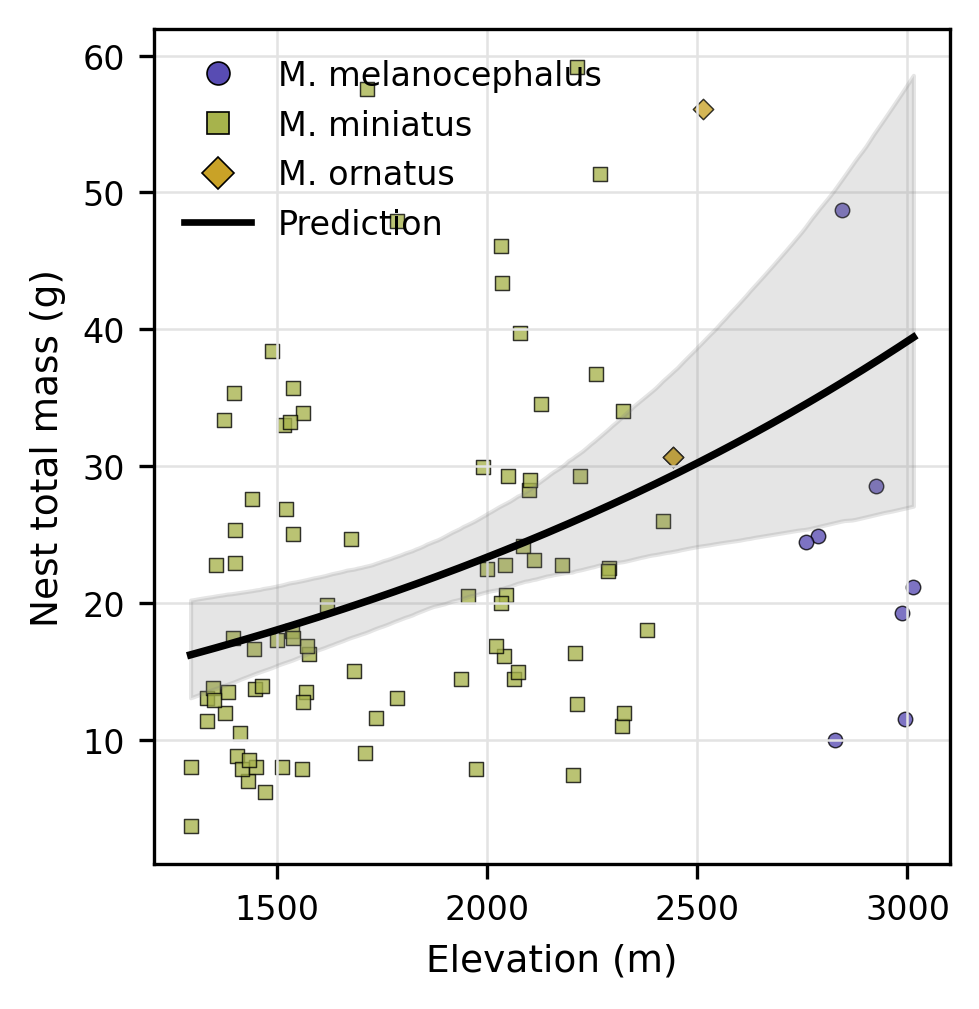

In [8]:
import os
os.makedirs("Figures", exist_ok=True)

label_fontsize = 9
tick_fontsize = 8
legend_fontsize = 8
paper_facecolor = "white"
grid_color = "#E3E3E3"

species_labels = {
    "Myioborus_melanocephalus": "M. melanocephalus",
    "Myioborus_miniatus": "M. miniatus",
    "Myioborus_ornatus": "M. ornatus",
}
species_markers = {
    "Myioborus_melanocephalus": "o",
    "Myioborus_miniatus": "s",
    "Myioborus_ornatus": "D",
}
species_colors = {
    "Myioborus_melanocephalus": "#584CB3",
    "Myioborus_miniatus": "#A7B34C",
    "Myioborus_ornatus": "#C9A227",
}

species_order_plot = [sp for sp in species_order if sp in df_model["Especie"].unique()]

fig, ax = plt.subplots(figsize=(3.15, 3.25), dpi=300, constrained_layout=True)
fig.patch.set_facecolor(paper_facecolor)
ax.set_facecolor(paper_facecolor)

for sp in species_order_plot:
    sub = df_model[df_model["Especie"] == sp]
    ax.scatter(
        sub["Elevacion"],
        sub["Nido_peso_Total_g"],
        marker=species_markers[sp],
        s=12,
        alpha=0.78,
        color=species_colors[sp],
        edgecolor="black",
        linewidth=0.35,
        zorder=1,
    )

ax.plot(
    pred_df["Elevacion"],
    pred_df["predicted"],
    linewidth=1.8,
    color="black",
    zorder=3,
)

ax.fill_between(
    pred_df["Elevacion"],
    pred_df["ci_low"],
    pred_df["ci_high"],
    alpha=0.20,
    color="gray",
    zorder=2,
)

legend_elements = [
    Line2D(
        [0], [0],
        marker=species_markers[sp],
        linestyle="None",
        markersize=5.5,
        markerfacecolor=species_colors[sp],
        markeredgecolor="black",
        markeredgewidth=0.4,
        color="none",
        label=species_labels[sp],
    )
    for sp in species_order_plot
]
legend_elements.append(
    Line2D(
        [0], [0],
        linestyle="-",
        linewidth=1.6,
        color="black",
        label="Prediction",
    )
)

ax.legend(handles=legend_elements, frameon=False, fontsize=legend_fontsize, loc="best")
ax.set_xlabel("Elevation (m)", fontsize=label_fontsize)
ax.set_ylabel("Nest total mass (g)", fontsize=label_fontsize)
ax.grid(True, color=grid_color, linewidth=0.6)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.tick_params(axis="both", labelsize=tick_fontsize)

fig.savefig("glm_nest_weight_adjusted_prediction.png", dpi=300, facecolor=paper_facecolor, bbox_inches="tight")
fig.savefig("Figures/glm_nest_weight_adjusted_prediction.png", dpi=300, facecolor=paper_facecolor, bbox_inches="tight")
plt.show()

The next block asks whether the whole-nest pattern is concentrated in a particular structural layer. By repeating the modelling logic for the first layer, the notebook tests whether layer-specific mass helps explain the broader change in total nest mass without assuming that every nest component responds in the same way.

### First-layer mass

In [9]:
# Nest-level dataset for Capa_1_g
myi_nest_capa1 = myi.dropna(subset=['ID_del_Nido', 'Capa_1_g']).copy()

# Keep only one row per nest
myi_nest_capa1 = myi_nest_capa1.drop_duplicates(
    subset='ID_del_Nido',
    keep='first'
).copy()

print("Nest-level rows:", myi_nest_capa1.shape[0])
print("Unique nest IDs:", myi_nest_capa1['ID_del_Nido'].nunique())

display(myi_nest_capa1.head())

Nest-level rows: 96
Unique nest IDs: 96


,Estacion,Numero_Libreta,Pagina,Año,Familia,Especie,ID_del_Nido,N,S,W,...,nota comportamental. Observacion en campo.,Nota 1,eclosion,nota,puesta,periodo huevos,periodo pollos,t.huevos(dias),t.pollos(dias),nota.1
2,Road_San_Pedro,1,63,2009,Parulidae,Myioborus_miniatus,01_SPR09a,NaN,"13°05´47,6""","71°33´50,6""",...,NaN,-,-,-,-,-,-,-,-,-
7,Road_San_Pedro,1,87,2009,Parulidae,Myioborus_miniatus,02_SPR09,NaN,"13°07´21,8""","71°34´17,6""",...,NaN,-,-,-,-,-,-,-,-,-
13,Chicoral,1_Tatama,33,2014,Parulidae,Myioborus_miniatus,CH01_GJDR14,"03°34´73.4""",NaN,"76°34´43.5""",...,NaN,-,-,-,-,-,-,-,-,-
15,Chicoral,1,3,2015,Parulidae,Myioborus_miniatus,CH03_ACC15,NaN,NaN,76.5833,...,NaN,-,-,-,-,-,-,-,-,-
24,Chicoral,1,31,2015,Parulidae,Myioborus_miniatus,CH06_AMM15,NaN,NaN,76.5836,...,NaN,-,-,-,-,-,-,-,-,-


In [10]:
df_model_capa1 = myi_nest_capa1.copy()

# Convert numeric columns
df_model_capa1['Capa_1_g'] = pd.to_numeric(
    df_model_capa1['Capa_1_g'],
    errors='coerce'
)

df_model_capa1['Elevacion'] = pd.to_numeric(
    df_model_capa1['Elevacion'],
    errors='coerce'
)

# Keep only complete cases for this model
df_model_capa1 = df_model_capa1.dropna(subset=[
    'Capa_1_g',
    'Especie',
    'Elevacion'
]).copy()

# Gamma GLM needs strictly positive Y values
df_model_capa1 = df_model_capa1[df_model_capa1['Capa_1_g'] > 0].copy()

# Create centred elevation variable
mean_elev_capa1 = df_model_capa1['Elevacion'].mean()
df_model_capa1['Elevacion_c_1000'] = (
    df_model_capa1['Elevacion'] - mean_elev_capa1
) / 1000

print("Mean elevation used for centring:", mean_elev_capa1)
print("Rows used in model:", df_model_capa1.shape[0])

display(
    df_model_capa1[
        ['ID_del_Nido', 'Especie', 'Elevacion', 'Elevacion_c_1000', 'Capa_1_g']
    ].head()
)

Mean elevation used for centring: 1851.8181818181818
Rows used in model: 88


,ID_del_Nido,Especie,Elevacion,Elevacion_c_1000,Capa_1_g
2,01_SPR09a,Myioborus_miniatus,1938.0,0.086182,7.40
7,02_SPR09,Myioborus_miniatus,2178.0,0.326182,18.40
13,CH01_GJDR14,Myioborus_miniatus,2036.0,0.184182,30.64
15,CH03_ACC15,Myioborus_miniatus,2034.0,0.182182,16.32
24,CH06_AMM15,Myioborus_miniatus,2040.0,0.188182,9.77


In [11]:
glm_capa1 = smf.glm(
    formula='Capa_1_g ~ C(Especie) + Elevacion_c_1000',
    data=df_model_capa1,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(glm_capa1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               Capa_1_g   No. Observations:                   88
Model:                            GLM   Df Residuals:                       84
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                         0.53314
Method:                          IRLS   Log-Likelihood:                -295.38
Date:                Fri, 08 May 2026   Deviance:                       48.484
Time:                        00:05:30   Pearson chi2:                     44.8
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1522
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [12]:
# -----------------------------
# labels and markers
# -----------------------------
species_labels = {
    'Myioborus_melanocephalus': 'M. melanocephalus',
    'Myioborus_miniatus': 'M. miniatus',
    'Myioborus_ornatus': 'M. ornatus'
}

species_markers = {
    'Myioborus_melanocephalus': 'o',
    'Myioborus_miniatus': 's',
    'Myioborus_ornatus': 'D'
}

species_order = [
    'Myioborus_melanocephalus',
    'Myioborus_miniatus',
    'Myioborus_ornatus'
]

# -----------------------------
# elevation sequence
# -----------------------------
elev_min = df_model_capa1['Elevacion'].min()
elev_max = df_model_capa1['Elevacion'].max()
elev_seq = np.linspace(elev_min, elev_max, 200)

# This is the mean elevation used in the Capa_1_g model
mean_elev_capa1 = df_model_capa1['Elevacion'].mean()

# -----------------------------
# adjusted marginal prediction from glm_capa1
# averaged over observed species composition
# -----------------------------
design_info = glm_capa1.model.data.design_info
beta_hat = glm_capa1.params.values
cov_beta = glm_capa1.cov_params().values

# For CI simulation
n_sim = 2000
rng = np.random.default_rng(123)
beta_sim = rng.multivariate_normal(beta_hat, cov_beta, size=n_sim)

pred_rows = []

for elev in elev_seq:
    tmp = pd.DataFrame({
        'Especie': df_model_capa1['Especie'].values,
        'Elevacion_c_1000': np.repeat((elev - mean_elev_capa1) / 1000, len(df_model_capa1))
    })

    # Build design matrix like the fitted model
    X = build_design_matrices([design_info], tmp)[0]
    X = np.asarray(X)

    # Point prediction
    eta_hat = X @ beta_hat
    mu_hat = np.exp(eta_hat)
    pred_mean = mu_hat.mean()

    # Simulated CI
    eta_sim = X @ beta_sim.T
    mu_sim = np.exp(eta_sim)
    pred_sim_mean = mu_sim.mean(axis=0)

    ci_low = np.percentile(pred_sim_mean, 2.5)
    ci_high = np.percentile(pred_sim_mean, 97.5)

    pred_rows.append({
        'Elevacion': elev,
        'predicted': pred_mean,
        'ci_low': ci_low,
        'ci_high': ci_high
    })

pred_df_capa1 = pd.DataFrame(pred_rows)


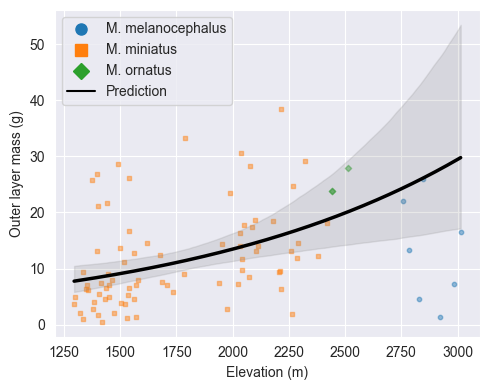

In [91]:
# plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 4))

# optional: species colors from default matplotlib cycle
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
species_colors = {
    species_order[i]: color_cycle[i % len(color_cycle)]
    for i in range(len(species_order))
}

# real points by species
for sp in species_order:
    sub = df_model_capa1[df_model_capa1['Especie'] == sp]

    ax.scatter(
        sub['Elevacion'],
        sub['Capa_1_g'],
        marker=species_markers[sp],
        s=10,
        alpha=0.45,
        color=species_colors[sp],
        zorder=1
    )

# one adjusted predictive line from glm_capa1
ax.plot(
    pred_df_capa1['Elevacion'],
    pred_df_capa1['predicted'],
    linewidth=2.5,
    color='black',
    zorder=3
)

ax.fill_between(
    pred_df_capa1['Elevacion'],
    pred_df_capa1['ci_low'],
    pred_df_capa1['ci_high'],
    alpha=0.18,
    color='gray',
    zorder=1
)

# custom legend
legend_elements = [
    Line2D(
        [0], [0],
        marker=species_markers[sp],
        linestyle='None',
        markersize=8,
        color=species_colors[sp],
        label=species_labels[sp]
    )
    for sp in species_order
]

legend_elements.append(
    Line2D(
        [0], [0],
        linestyle='-',
        linewidth=1.5,
        color='black',
        label='Prediction'
    )
)

ax.legend(handles=legend_elements, frameon=True)

ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Outer layer mass (g)')
ax.set_title('')

plt.tight_layout()
#fig.savefig("glm_capa1_adjusted_prediction.png", dpi=300, bbox_inches='tight')
plt.show()

In [13]:
species_labels = {
    'Myioborus_melanocephalus': 'M. melanocephalus',
    'Myioborus_miniatus': 'M. miniatus',
    'Myioborus_ornatus': 'M. ornatus'
}

species_markers = {
    'Myioborus_melanocephalus': 'o',
    'Myioborus_miniatus': 's',
    'Myioborus_ornatus': 'D'
}

species_colors = {
    'Myioborus_melanocephalus': "#584CB3",
    'Myioborus_miniatus': "#A7B34C",
    'Myioborus_ornatus': "#C9A227"   # mostaza
}

species_order = [
    'Myioborus_melanocephalus',
    'Myioborus_miniatus',
    'Myioborus_ornatus'
]

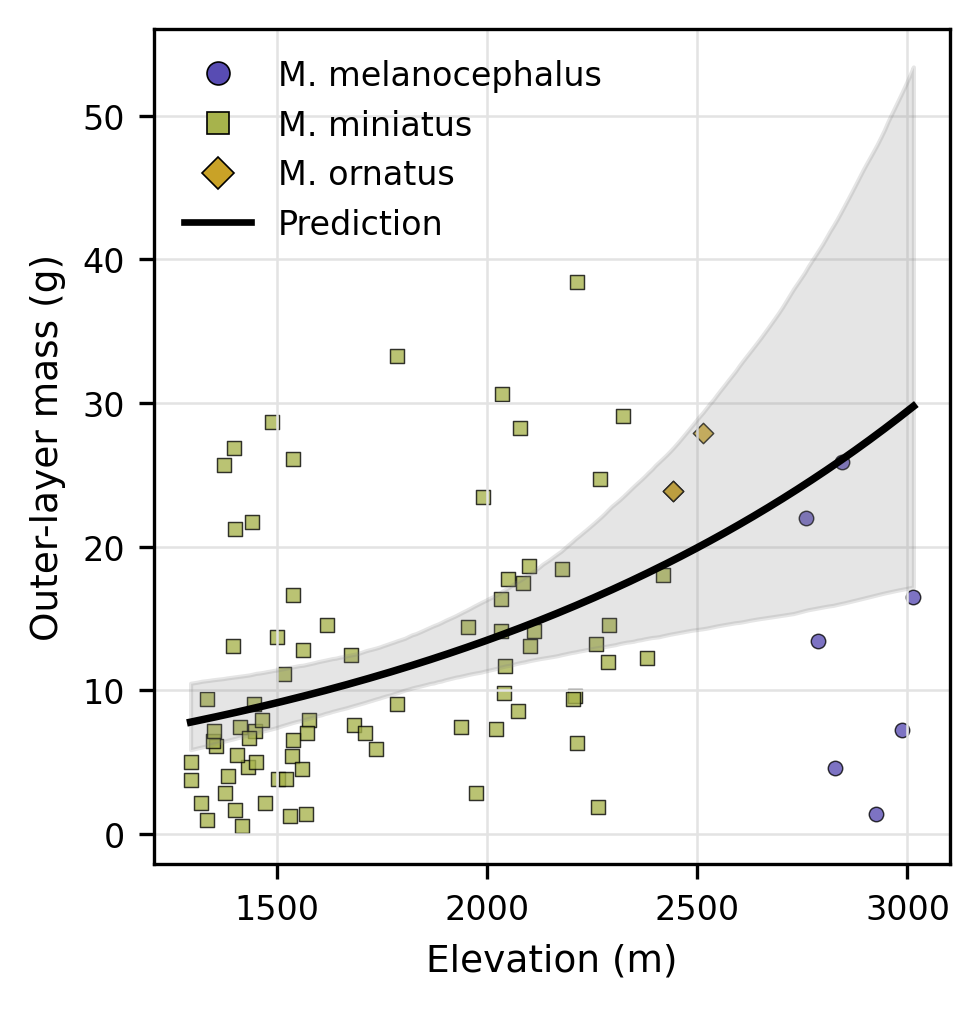

In [14]:
os.makedirs("Figures", exist_ok=True)

label_fontsize = 9
tick_fontsize = 8
legend_fontsize = 8
paper_facecolor = "white"
grid_color = "#E3E3E3"

fig, ax = plt.subplots(figsize=(3.15, 3.25), dpi=300, constrained_layout=True)
fig.patch.set_facecolor(paper_facecolor)
ax.set_facecolor(paper_facecolor)

for sp in species_order:
    sub = df_model_capa1[df_model_capa1["Especie"] == sp]
    ax.scatter(
        sub["Elevacion"],
        sub["Capa_1_g"],
        marker=species_markers.get(sp, "o"),
        s=12,
        alpha=0.78,
        color=species_colors.get(sp, "gray"),
        edgecolor="black",
        linewidth=0.35,
        label=species_labels.get(sp, sp),
        zorder=1,
    )

ax.plot(
    pred_df_capa1["Elevacion"],
    pred_df_capa1["predicted"],
    linewidth=1.8,
    color="black",
    zorder=3,
)

ax.fill_between(
    pred_df_capa1["Elevacion"],
    pred_df_capa1["ci_low"],
    pred_df_capa1["ci_high"],
    color="gray",
    alpha=0.20,
    zorder=2,
)

legend_elements = [
    Line2D(
        [0], [0],
        marker=species_markers[sp],
        linestyle="None",
        markersize=5.5,
        markerfacecolor=species_colors[sp],
        markeredgecolor="black",
        markeredgewidth=0.4,
        color="none",
        label=species_labels[sp],
    )
    for sp in species_order
]
legend_elements.append(
    Line2D(
        [0], [0],
        linestyle="-",
        linewidth=1.6,
        color="black",
        label="Prediction",
    )
)

ax.legend(handles=legend_elements, frameon=False, fontsize=legend_fontsize, loc="best")
ax.set_xlabel("Elevation (m)", fontsize=label_fontsize)
ax.set_ylabel("Outer-layer mass (g)", fontsize=label_fontsize)
ax.grid(True, color=grid_color, linewidth=0.6)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.tick_params(axis="both", labelsize=tick_fontsize)

fig.savefig("glm_capa1_adjusted_prediction.png", dpi=300, facecolor=paper_facecolor, bbox_inches="tight")
fig.savefig("Figures/glm_capa1_adjusted_prediction.png", dpi=300, facecolor=paper_facecolor, bbox_inches="tight")
plt.show()

In [92]:
# elevation sequence
elev_min = df_model_capa1['Elevacion'].min()
elev_max = df_model_capa1['Elevacion'].max()
elev_seq = np.linspace(elev_min, elev_max, 200)

mean_elev_capa1 = df_model_capa1['Elevacion'].mean()

# adjusted marginal prediction from glm_capa1
design_info = glm_capa1.model.data.design_info
beta_hat = glm_capa1.params.values
cov_beta = glm_capa1.cov_params().values

# for CI simulation
n_sim = 2000
rng = np.random.default_rng(123)
beta_sim = rng.multivariate_normal(beta_hat, cov_beta, size=n_sim)

pred_rows = []

for elev in elev_seq:
    tmp = pd.DataFrame({
        'Especie': df_model_capa1['Especie'].values,
        'Elevacion_c_1000': np.repeat((elev - mean_elev_capa1) / 1000, len(df_model_capa1))
    })

    X = build_design_matrices([design_info], tmp)[0]
    X = np.asarray(X)

    eta_hat = X @ beta_hat
    mu_hat = np.exp(eta_hat)
    pred_mean = mu_hat.mean()

    eta_sim = X @ beta_sim.T
    mu_sim = np.exp(eta_sim)
    pred_sim_mean = mu_sim.mean(axis=0)

    ci_low = np.percentile(pred_sim_mean, 2.5)
    ci_high = np.percentile(pred_sim_mean, 97.5)

    pred_rows.append({
        'Elevacion': elev,
        'predicted': pred_mean,
        'ci_low': ci_low,
        'ci_high': ci_high
    })

pred_df_capa1 = pd.DataFrame(pred_rows)

display(pred_df_capa1.head())

,Elevacion,predicted,ci_low,ci_high
0,1295.000000,7.760868,5.843951,10.471504
1,1303.638191,7.813470,5.902667,10.510084
2,1312.276382,7.866428,5.964645,10.552211
3,1320.914573,7.919745,6.024979,10.607489
4,1329.552764,7.973424,6.087431,10.638973


In [93]:
# Model design info
design_info = glm_capa1.model.data.design_info

# New data for species comparisons at mean elevation
contrast_data = pd.DataFrame({
    'Especie': species_order,
    'Elevacion_c_1000': [0] * len(species_order)
})

# Build design matrix exactly as in fitted model
X = build_design_matrices([design_info], contrast_data)[0]
X = np.asarray(X)

beta = glm_capa1.params.values
cov_beta = glm_capa1.cov_params().values

results = []

for i, j in combinations(range(len(species_order)), 2):
    sp1 = species_order[i]
    sp2 = species_order[j]

    # Contrast on the log scale
    L = X[i, :] - X[j, :]

    estimate_log = L @ beta
    se = np.sqrt(L @ cov_beta @ L.T)

    z_value = estimate_log / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_value)))

    ci_low_log = estimate_log - 1.96 * se
    ci_high_log = estimate_log + 1.96 * se

    results.append({
        'comparison': f"{species_labels[sp1]} / {species_labels[sp2]}",
        'log_ratio': estimate_log,
        'SE': se,
        'z': z_value,
        'p_value': p_value,
        'ratio': np.exp(estimate_log),
        'ratio_ci_low': np.exp(ci_low_log),
        'ratio_ci_high': np.exp(ci_high_log)
    })

posthoc_species_capa1 = pd.DataFrame(results)

# Adjust p-values for multiple comparisons
posthoc_species_capa1['p_holm'] = multipletests(
    posthoc_species_capa1['p_value'],
    method='holm'
)[1]

display(posthoc_species_capa1)

,comparison,log_ratio,SE,z,p_value,ratio,ratio_ci_low,ratio_ci_high,p_holm
0,M. melanocephalus / M. miniatus,-0.737881,0.397987,-1.854031,0.063735,0.478126,0.219164,1.043076,0.179574
1,M. melanocephalus / M. ornatus,-0.966327,0.513502,-1.881837,0.059858,0.380478,0.139068,1.040953,0.179574
2,M. miniatus / M. ornatus,-0.228447,0.464069,-0.492269,0.622529,0.795769,0.320452,1.976106,0.622529


### Nest height above ground

This section tests whether nest placement above ground changes with species identity or elevation once the data are reduced to one observation per nest. Framing the response at the nest level is important here because placement is a property of the nest site rather than of any individual egg or chick.

In [94]:
myi_nest_altura = myi.dropna(subset=['ID_del_Nido', 'Altura_sobre_el_suelo_cm']).copy()

# Keep only one row per nest
myi_nest_altura = myi_nest_altura.drop_duplicates(
    subset='ID_del_Nido',
    keep='first'
).copy()

print("Nest-level rows:", myi_nest_altura.shape[0])
print("Unique nest IDs:", myi_nest_altura['ID_del_Nido'].nunique())

display(myi_nest_altura.head())

Nest-level rows: 127
Unique nest IDs: 127


,Estacion,Especie,ID_del_Nido,Elevacion,Fecha_de_encuentro,Huevo_o_Polluelo,Nido_Int_Largo_mm,Nido_Int_Ancho_mm,Nido_Int_Espesor_mm,Nido_Int_Profundidad_1_mm,...,Capa_2_g,Capa_3_g,Capa_4_g,ID_del_Huevo,Huevo_Largo_mm,Huevo_Ancho_mm,Huevo_Peso_g,Numero_de_Huevos,Latitude,Longitude
0,San_Pedro,Myioborus_melanocephalus,01_SPR09,1949.0,26-Aug-09,Huevo,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1A,16.9,12.5,1.50,2.0,-13.101500,-71.565700
2,San_Pedro,Myioborus_miniatus,01_SPR09a,1938.0,02-Oct-09,Huevo,NaN,NaN,NaN,NaN,...,7.04,NaN,NaN,1A,17.2,13.2,1.55,3.0,-13.096556,-71.564056
7,San_Pedro,Myioborus_miniatus,02_SPR09,2178.0,06-Oct-09,Huevo,45.8,57.0,18.0,26.5,...,4.4,NaN,NaN,1A,18.1,13.9,1.70,2.0,-13.122722,-71.571556
9,San_Pedro,Myioborus_miniatus,1SP_07,NaN,19-Aug-07,Polluelo,43.4,47.4,27.3,59.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
10,San_Pedro,Myioborus_miniatus,3SP_07,NaN,03-Oct-07,Huevo,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1,17.6,13.8,1.80,1.0,NaN,NaN


In [95]:
df_model_altura = myi_nest_altura.copy()

# Convert numeric columns
df_model_altura['Altura_sobre_el_suelo_cm'] = pd.to_numeric(
    df_model_altura['Altura_sobre_el_suelo_cm'],
    errors='coerce'
)

df_model_altura['Elevacion'] = pd.to_numeric(
    df_model_altura['Elevacion'],
    errors='coerce'
)

# Keep only complete cases
df_model_altura = df_model_altura.dropna(subset=[
    'Altura_sobre_el_suelo_cm',
    'Especie',
    'Elevacion'
]).copy()

# Gamma GLM needs strictly positive Y values
df_model_altura = df_model_altura[df_model_altura['Altura_sobre_el_suelo_cm'] > 0].copy()

# Create centred elevation variable
mean_elev_altura = df_model_altura['Elevacion'].mean()

df_model_altura['Elevacion_c_1000'] = (
    df_model_altura['Elevacion'] - mean_elev_altura
) / 1000

print("Mean elevation used for centring:", mean_elev_altura)
print("Rows used in model:", df_model_altura.shape[0])

display(
    df_model_altura[
        ['ID_del_Nido', 'Especie', 'Elevacion', 'Elevacion_c_1000', 'Altura_sobre_el_suelo_cm']
    ].head()
)

Mean elevation used for centring: 1845.7766990291261
Rows used in model: 103


,ID_del_Nido,Especie,Elevacion,Elevacion_c_1000,Altura_sobre_el_suelo_cm
0,01_SPR09,Myioborus_melanocephalus,1949.0,0.103223,120.0
2,01_SPR09a,Myioborus_miniatus,1938.0,0.092223,120.0
7,02_SPR09,Myioborus_miniatus,2178.0,0.332223,120.0
13,CH01_GJDR14,Myioborus_miniatus,2036.0,0.190223,120.0
15,CH03_ACC15,Myioborus_miniatus,2034.0,0.188223,300.0


In [96]:
glm_altura = smf.glm(
    formula='Altura_sobre_el_suelo_cm ~ C(Especie) + Elevacion_c_1000',
    data=df_model_altura,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(glm_altura.summary())

                    Generalized Linear Model Regression Results                     
Dep. Variable:     Altura_sobre_el_suelo_cm   No. Observations:                  103
Model:                                  GLM   Df Residuals:                       99
Model Family:                         Gamma   Df Model:                            3
Link Function:                          Log   Scale:                         0.54820
Method:                                IRLS   Log-Likelihood:                -569.64
Date:                      Thu, 07 May 2026   Deviance:                       62.848
Time:                              22:25:10   Pearson chi2:                     54.3
No. Iterations:                          11   Pseudo R-squ. (CS):            0.07324
Covariance Type:                  nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

In [97]:
df_model_altura['Especie'].value_counts()

Especie
Myioborus_miniatus          92
Myioborus_melanocephalus     7
Myioborus_ornatus            4
Name: count, dtype: int64

Nest height above ground showed no clear association with elevation. Although the model estimated lower nest height for *M. ornatus* relative to the reference species, this result should be interpreted cautiously because the species was represented with few nests. Therefore, we do not treat this species-level difference as robust evidence.

## Egg and clutch traits

### Clutch size

The notebook now shifts from nest construction to reproductive traits, beginning with clutch size because it is naturally defined once per nest. This keeps the analysis aligned with the biological scale of the response before moving on to egg-level measurements such as length, width, elongation, volume, and mass.

In [98]:
#myi.columns
myi_nest_huevos = myi.dropna(subset=['ID_del_Nido', 'Numero_de_Huevos']).copy()

# Keep only one row per nest
myi_nest_huevos = myi_nest_huevos.drop_duplicates(
    subset='ID_del_Nido',
    keep='first'
).copy()

print("Nest-level rows:", myi_nest_huevos.shape[0])
print("Unique nest IDs:", myi_nest_huevos['ID_del_Nido'].nunique())

display(myi_nest_huevos.head())

Nest-level rows: 143
Unique nest IDs: 143


,Estacion,Especie,ID_del_Nido,Elevacion,Fecha_de_encuentro,Huevo_o_Polluelo,Nido_Int_Largo_mm,Nido_Int_Ancho_mm,Nido_Int_Espesor_mm,Nido_Int_Profundidad_1_mm,...,Capa_2_g,Capa_3_g,Capa_4_g,ID_del_Huevo,Huevo_Largo_mm,Huevo_Ancho_mm,Huevo_Peso_g,Numero_de_Huevos,Latitude,Longitude
0,San_Pedro,Myioborus_melanocephalus,01_SPR09,1949.0,26-Aug-09,Huevo,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1A,16.9,12.5,1.50,2.0,-13.101500,-71.565700
2,San_Pedro,Myioborus_miniatus,01_SPR09a,1938.0,02-Oct-09,Huevo,NaN,NaN,NaN,NaN,...,7.04,NaN,NaN,1A,17.2,13.2,1.55,3.0,-13.096556,-71.564056
7,San_Pedro,Myioborus_miniatus,02_SPR09,2178.0,06-Oct-09,Huevo,45.8,57.0,18.0,26.5,...,4.4,NaN,NaN,1A,18.1,13.9,1.70,2.0,-13.122722,-71.571556
9,San_Pedro,Myioborus_miniatus,1SP_07,NaN,19-Aug-07,Polluelo,43.4,47.4,27.3,59.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
10,San_Pedro,Myioborus_miniatus,3SP_07,NaN,03-Oct-07,Huevo,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1,17.6,13.8,1.80,1.0,NaN,NaN


In [99]:
df_model_huevos = myi_nest_huevos.copy()

# Convert numeric columns
df_model_huevos['Numero_de_Huevos'] = pd.to_numeric(
    df_model_huevos['Numero_de_Huevos'],
    errors='coerce'
)

df_model_huevos['Elevacion'] = pd.to_numeric(
    df_model_huevos['Elevacion'],
    errors='coerce'
)

# Keep only complete cases
df_model_huevos = df_model_huevos.dropna(subset=[
    'Numero_de_Huevos',
    'Especie',
    'Elevacion'
]).copy()

# Keep only biologically valid counts
df_model_huevos = df_model_huevos[df_model_huevos['Numero_de_Huevos'] >= 0].copy()

# Optional: check values
print("Egg number distribution:")
display(df_model_huevos['Numero_de_Huevos'].value_counts().sort_index())

print("Rows used in model:", df_model_huevos.shape[0])
print("Unique nests:", df_model_huevos['ID_del_Nido'].nunique())

# Create centred elevation variable
mean_elev_huevos = df_model_huevos['Elevacion'].mean()

df_model_huevos['Elevacion_c_1000'] = (
    df_model_huevos['Elevacion'] - mean_elev_huevos
) / 1000

print("Mean elevation used for centring:", mean_elev_huevos)

display(
    df_model_huevos[
        ['ID_del_Nido', 'Especie', 'Elevacion', 'Elevacion_c_1000', 'Numero_de_Huevos']
    ].head()
)

Egg number distribution:


Numero_de_Huevos
1.0      8
2.0    111
3.0      8
Name: count, dtype: int64

Rows used in model: 127
Unique nests: 127
Mean elevation used for centring: 1861.4015748031495


,ID_del_Nido,Especie,Elevacion,Elevacion_c_1000,Numero_de_Huevos
0,01_SPR09,Myioborus_melanocephalus,1949.0,0.087598,2.0
2,01_SPR09a,Myioborus_miniatus,1938.0,0.076598,3.0
7,02_SPR09,Myioborus_miniatus,2178.0,0.316598,2.0
13,CH01_GJDR14,Myioborus_miniatus,2036.0,0.174598,2.0
16,CH03_RPG15,Myioborus_miniatus,1994.0,0.132598,2.0


In [100]:
glm_huevos = smf.glm(
    formula='Numero_de_Huevos ~ C(Especie) + Elevacion_c_1000',
    data=df_model_huevos,
    family=sm.families.Poisson(link=sm.families.links.Log())
).fit()

print(glm_huevos.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       Numero_de_Huevos   No. Observations:                  127
Model:                            GLM   Df Residuals:                      123
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -169.08
Date:                Thu, 07 May 2026   Deviance:                       8.1111
Time:                        22:25:10   Pearson chi2:                     7.68
No. Iterations:                     4   Pseudo R-squ. (CS):           0.002052
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [101]:
dispersion_huevos = glm_huevos.pearson_chi2 / glm_huevos.df_resid

print("Dispersion:", dispersion_huevos)

Dispersion: 0.062422803323896346


The dispersion estimate is extremely low, which matches the visual impression that clutch size varies very little in this dataset. That result is useful context here: even a formally fitted count model has little biological variation to explain once nearly all nests fall into the same clutch-size range.

In [102]:
display(
    df_model_huevos['Numero_de_Huevos']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'index': 'Numero_de_Huevos', 'Numero_de_Huevos': 'n'})
)

display(
    pd.crosstab(
        df_model_huevos['Especie'],
        df_model_huevos['Numero_de_Huevos']
    )
)

,n,count
0,1.0,8
1,2.0,111
2,3.0,8


Numero_de_Huevos,1.0,2.0,3.0
Especie,,,
Myioborus_melanocephalus,1,8,0
Myioborus_miniatus,6,99,8
Myioborus_ornatus,1,4,0


In [103]:
coef_table_huevos = pd.DataFrame({
    "term": glm_huevos.params.index,
    "coef_log_scale": glm_huevos.params.values,
    "multiplicative_effect": np.exp(glm_huevos.params.values),
    "p_value": glm_huevos.pvalues.values
})

display(coef_table_huevos)

print("Reference species expected number of eggs at mean elevation:")
print(np.exp(glm_huevos.params["Intercept"]))

,term,coef_log_scale,multiplicative_effect,p_value
0,Intercept,0.680610,1.975083,0.017904
1,C(Especie)[T.Myioborus_miniatus],0.016083,1.016213,0.957985
2,C(Especie)[T.Myioborus_ornatus],-0.058319,0.943349,0.887892
3,Elevacion_c_1000,-0.051895,0.949429,0.773293


Reference species expected number of eggs at mean elevation:
1.9750828375251612


Clutch size showed very little variation across nests, with most nests containing about two eggs. The Poisson GLM therefore provides no evidence that egg number changes systematically with species or elevation in this dataset.

### Egg length × width

This section first asks how tightly egg length and width covary across species before moving to more derived descriptors such as elongation or volume. The goal is to separate broad scaling relationships from any more specific taxonomic or elevational shifts in egg shape.

In [15]:
df_egg = myi.copy()

df_egg['Huevo_Largo_mm'] = pd.to_numeric(
    df_egg['Huevo_Largo_mm'],
    errors='coerce'
)

df_egg['Huevo_Ancho_mm'] = pd.to_numeric(
    df_egg['Huevo_Ancho_mm'],
    errors='coerce'
)

df_egg = df_egg.dropna(subset=[
    'Huevo_Largo_mm',
    'Huevo_Ancho_mm',
    'Especie'
]).copy()

# Optional: if each egg has a unique ID and repeated rows exist, uncomment this
# df_egg = df_egg.drop_duplicates(subset='ID_del_Huevo', keep='first').copy()

print("Rows used:", df_egg.shape[0])
display(df_egg[['Especie', 'ID_del_Nido', 'ID_del_Huevo', 'Huevo_Largo_mm', 'Huevo_Ancho_mm']].head())
display(df_egg['Especie'].value_counts())

Rows used: 258


,Especie,ID_del_Nido,ID_del_Huevo,Huevo_Largo_mm,Huevo_Ancho_mm
0,Myioborus_melanocephalus,01_SPR09,1A,16.9,12.5
1,Myioborus_melanocephalus,01_SPR09,2B,16.9,12.8
2,Myioborus_miniatus,01_SPR09a,1A,17.2,13.2
3,Myioborus_miniatus,01_SPR09a,2B,18.0,13.0
4,Myioborus_miniatus,01_SPR09a,3C,16.9,13.0


Especie
Myioborus_miniatus          233
Myioborus_melanocephalus     17
Myioborus_ornatus             7
Myioborus_sp.                 1
Name: count, dtype: int64

In [16]:
species_labels = {
    'Myioborus_melanocephalus': 'M. melanocephalus',
    'Myioborus_miniatus': 'M. miniatus',
    'Myioborus_ornatus': 'M. ornatus'
}

species_markers = {
    'Myioborus_melanocephalus': 'o',
    'Myioborus_miniatus': 's',
    'Myioborus_ornatus': 'D'
}

species_order = [
    'Myioborus_melanocephalus',
    'Myioborus_miniatus',
    'Myioborus_ornatus'
]

# Keep only species present in the data
species_order_plot = [sp for sp in species_order if sp in df_egg['Especie'].unique()]

# -------------------------------------------------
# Fit simple overall regression for visual trend
# -------------------------------------------------
egg_lm = smf.ols(
    formula='Huevo_Largo_mm ~ Huevo_Ancho_mm',
    data=df_egg
).fit()

x_seq = np.linspace(
    df_egg['Huevo_Ancho_mm'].min(),
    df_egg['Huevo_Ancho_mm'].max(),
    200
)

pred_df_egg = pd.DataFrame({
    'Huevo_Ancho_mm': x_seq
})

pred = egg_lm.get_prediction(pred_df_egg).summary_frame()

pred_df_egg['predicted'] = pred['mean']
pred_df_egg['ci_low'] = pred['mean_ci_lower']
pred_df_egg['ci_high'] = pred['mean_ci_upper']

print(egg_lm.summary())

                            OLS Regression Results                            
Dep. Variable:         Huevo_Largo_mm   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     80.38
Date:                Fri, 08 May 2026   Prob (F-statistic):           6.66e-17
Time:                        00:06:14   Log-Likelihood:                -366.77
No. Observations:                 258   AIC:                             737.5
Df Residuals:                     256   BIC:                             744.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.3662      1.593      2.

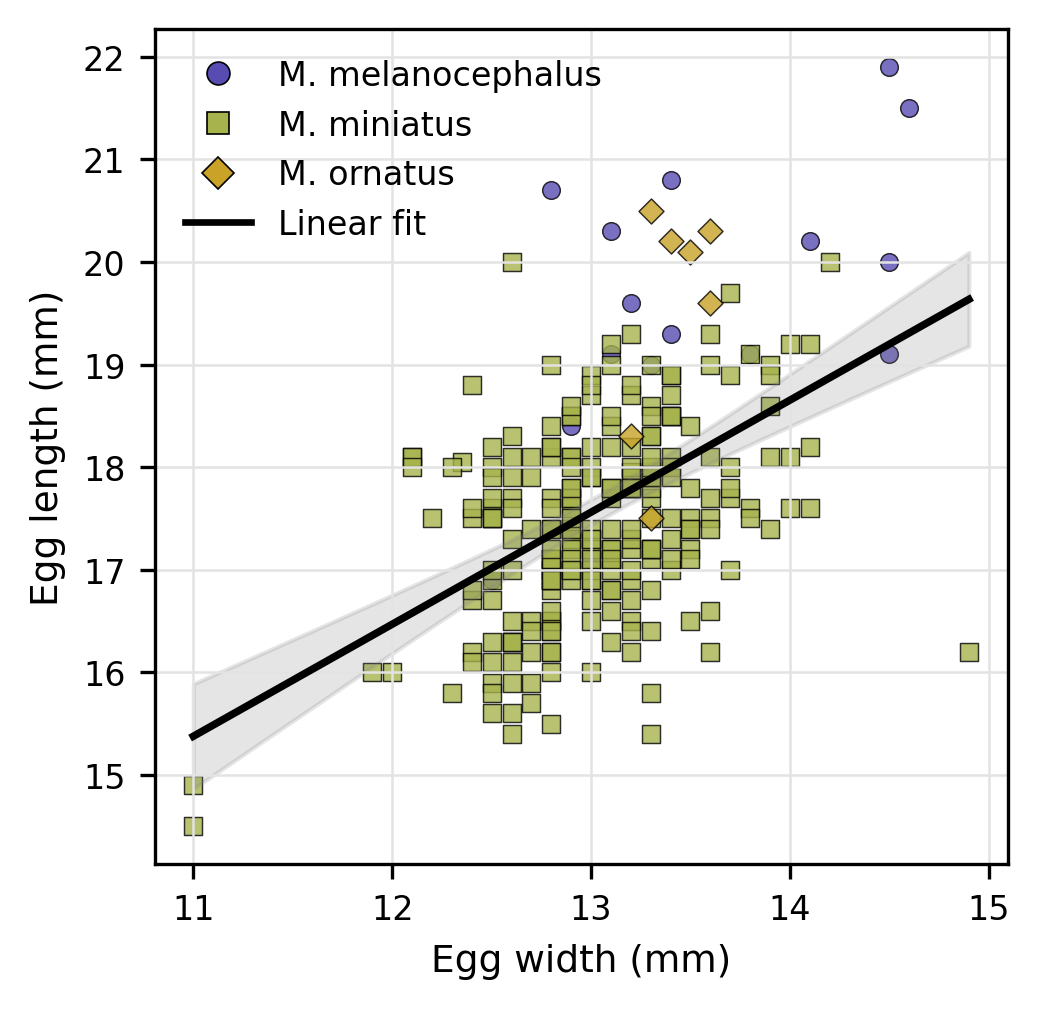

In [17]:
import os
os.makedirs("Figures", exist_ok=True)

label_fontsize = 9
tick_fontsize = 8
legend_fontsize = 8
paper_facecolor = "white"
grid_color = "#E3E3E3"

species_colors = {
    "Myioborus_melanocephalus": "#584CB3",
    "Myioborus_miniatus": "#A7B34C",
    "Myioborus_ornatus": "#C9A227",
}

fig, ax = plt.subplots(figsize=(3.35, 3.25), dpi=300, constrained_layout=True)
fig.patch.set_facecolor(paper_facecolor)
ax.set_facecolor(paper_facecolor)

for sp in species_order_plot:
    sub = df_egg[df_egg["Especie"] == sp]
    ax.scatter(
        sub["Huevo_Ancho_mm"],
        sub["Huevo_Largo_mm"],
        marker=species_markers[sp],
        s=18,
        alpha=0.8,
        color=species_colors.get(sp, "gray"),
        edgecolor="black",
        linewidth=0.35,
    )

ax.plot(
    pred_df_egg["Huevo_Ancho_mm"],
    pred_df_egg["predicted"],
    color="black",
    linewidth=1.8,
)

ax.fill_between(
    pred_df_egg["Huevo_Ancho_mm"],
    pred_df_egg["ci_low"],
    pred_df_egg["ci_high"],
    color="gray",
    alpha=0.20,
)

ax.set_xlabel("Egg width (mm)", fontsize=label_fontsize)
ax.set_ylabel("Egg length (mm)", fontsize=label_fontsize)
ax.tick_params(axis="both", labelsize=tick_fontsize)
ax.grid(True, color=grid_color, linewidth=0.6)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)

legend_elements = [
    Line2D(
        [0], [0],
        marker=species_markers[sp],
        linestyle="None",
        markersize=5.5,
        markerfacecolor=species_colors.get(sp, "gray"),
        markeredgecolor="black",
        markeredgewidth=0.4,
        color="none",
        label=species_labels[sp],
    )
    for sp in species_order_plot
]
legend_elements.append(
    Line2D(
        [0], [0],
        linestyle="-",
        linewidth=1.6,
        color="black",
        label="Linear fit",
    )
)

ax.legend(handles=legend_elements, frameon=False, fontsize=legend_fontsize, loc="best")

fig.savefig("Figures/Myioborus_egg_vs_sp.png", dpi=300, facecolor=paper_facecolor, bbox_inches="tight")
plt.show()

In [107]:
from scipy.stats import pearsonr, kruskal
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Variable de forma
df_egg['Egg_elongation'] = df_egg['Huevo_Largo_mm'] / df_egg['Huevo_Ancho_mm']

display(df_egg[['Especie', 'ID_del_Nido', 'ID_del_Huevo',
                'Huevo_Largo_mm', 'Huevo_Ancho_mm', 'Egg_elongation']].head())

,Especie,ID_del_Nido,ID_del_Huevo,Huevo_Largo_mm,Huevo_Ancho_mm,Egg_elongation
0,Myioborus_melanocephalus,01_SPR09,1A,16.9,12.5,1.352000
1,Myioborus_melanocephalus,01_SPR09,2B,16.9,12.8,1.320312
2,Myioborus_miniatus,01_SPR09a,1A,17.2,13.2,1.303030
3,Myioborus_miniatus,01_SPR09a,2B,18.0,13.0,1.384615
4,Myioborus_miniatus,01_SPR09a,3C,16.9,13.0,1.300000


In [52]:
egg_summary_species = (
    df_egg
    .groupby('Especie')
    .agg(
        n_eggs=('Egg_elongation', 'count'),
        mean_length_mm=('Huevo_Largo_mm', 'mean'),
        sd_length_mm=('Huevo_Largo_mm', 'std'),
        mean_width_mm=('Huevo_Ancho_mm', 'mean'),
        sd_width_mm=('Huevo_Ancho_mm', 'std'),
        mean_elongation=('Egg_elongation', 'mean'),
        sd_elongation=('Egg_elongation', 'std')
    )
    .reset_index()
)

display(egg_summary_species)

,Especie,n_eggs,mean_length_mm,sd_length_mm,mean_width_mm,sd_width_mm,mean_elongation,sd_elongation
0,Myioborus_melanocephalus,17,19.405882,1.487225,13.500000,0.694622,1.437707,0.088076
1,Myioborus_miniatus,233,17.448283,0.955055,13.026395,0.491392,1.340214,0.069877
2,Myioborus_ornatus,7,19.500000,1.150362,13.414286,0.157359,1.453383,0.078569


In [53]:
r_egg, p_egg = pearsonr(df_egg['Huevo_Ancho_mm'], df_egg['Huevo_Largo_mm'])

print(f"Egg-level Pearson correlation")
print(f"R = {r_egg:.3f}")
print(f"P = {p_egg:.4f}")

Egg-level Pearson correlation
R = 0.489
P = 0.0000


Egg length and egg width were positively correlated across Myioborus eggs. Mean egg elongation was similar among species, suggesting that egg shape is broadly conserved across the genus. Following Lizarazo and Londono, 2023.

### Egg volume

Egg volume following Hoyt 1979

In [56]:
# Variable de forma
df_egg['Egg_elongation'] = df_egg['Huevo_Largo_mm'] / df_egg['Huevo_Ancho_mm']

# Egg volume following Hoyt 1979
# V = 0.51 × length × width²
# Measurements are in mm, so divide by 1000 to obtain cm³
df_egg["Egg_volume_cm3"] = (
    0.51 *
    df_egg["Huevo_Largo_mm"] *
    (df_egg["Huevo_Ancho_mm"] ** 2)
) / 1000

display(df_egg[['Especie', 'ID_del_Nido', 'ID_del_Huevo',
                'Huevo_Largo_mm', 'Huevo_Ancho_mm',
                'Egg_elongation', 'Egg_volume_cm3']].head())

,Especie,ID_del_Nido,ID_del_Huevo,Huevo_Largo_mm,Huevo_Ancho_mm,Egg_elongation,Egg_volume_cm3
0,Myioborus_melanocephalus,01_SPR09,1A,16.9,12.5,1.352000,1.346719
1,Myioborus_melanocephalus,01_SPR09,2B,16.9,12.8,1.320312,1.412137
2,Myioborus_miniatus,01_SPR09a,1A,17.2,13.2,1.303030,1.528433
3,Myioborus_miniatus,01_SPR09a,2B,18.0,13.0,1.384615,1.551420
4,Myioborus_miniatus,01_SPR09a,3C,16.9,13.0,1.300000,1.456611


In [108]:
# Egg volume must be positive for log transform
df_egg_mixed = df_egg_mixed[df_egg_mixed['Egg_volume_cm3'] > 0].copy()

# Centre elevation
mean_elev_egg = df_egg_mixed['Elevacion'].mean()

df_egg_mixed['Elevacion_c_1000'] = (
    df_egg_mixed['Elevacion'] - mean_elev_egg
) / 1000

# Log volume for mixed model
df_egg_mixed['log_Egg_volume_cm3'] = np.log(df_egg_mixed['Egg_volume_cm3'])

print("Egg-level rows:", df_egg_mixed.shape[0])
print("Unique nests:", df_egg_mixed['ID_del_Nido'].nunique())
print("Mean elevation used for centring:", mean_elev_egg)

display(df_egg_mixed[
    ['ID_del_Nido', 'Especie', 'Elevacion', 'Elevacion_c_1000',
     'Egg_volume_cm3', 'log_Egg_volume_cm3', 'Egg_elongation']
].head())

display(df_egg_mixed['Especie'].value_counts())
display(df_egg_mixed['ID_del_Nido'].value_counts().describe())

Egg-level rows: 232
Unique nests: 120
Mean elevation used for centring: 1846.4439655172414


,ID_del_Nido,Especie,Elevacion,Elevacion_c_1000,Egg_volume_cm3,log_Egg_volume_cm3,Egg_elongation
0,01_SPR09,Myioborus_melanocephalus,1949.0,0.102556,1.346719,0.297671,1.352000
1,01_SPR09,Myioborus_melanocephalus,1949.0,0.102556,1.412137,0.345104,1.320312
2,01_SPR09a,Myioborus_miniatus,1938.0,0.091556,1.528433,0.424243,1.303030
3,01_SPR09a,Myioborus_miniatus,1938.0,0.091556,1.551420,0.439171,1.384615
4,01_SPR09a,Myioborus_miniatus,1938.0,0.091556,1.456611,0.376113,1.300000


Especie
Myioborus_miniatus          212
Myioborus_melanocephalus     13
Myioborus_ornatus             7
Name: count, dtype: int64

count    120.000000
mean       1.933333
std        0.424726
min        1.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        3.000000
Name: count, dtype: float64

In [109]:
mixed_egg_volume = smf.mixedlm(
    formula='log_Egg_volume_cm3 ~ C(Especie) + Elevacion_c_1000',
    data=df_egg_mixed,
    groups=df_egg_mixed['ID_del_Nido']
).fit(reml=False, method='lbfgs')

print(mixed_egg_volume.summary())

                   Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    log_Egg_volume_cm3
No. Observations:      232        Method:                ML                
No. Groups:            120        Scale:                 0.0026            
Min. group size:       1          Log-Likelihood:        234.5444          
Max. group size:       3          Converged:             Yes               
Mean group size:       1.9                                                 
---------------------------------------------------------------------------
                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                         0.506    0.047 10.746 0.000  0.414  0.598
C(Especie)[T.Myioborus_miniatus] -0.092    0.049 -1.873 0.061 -0.189  0.004
C(Especie)[T.Myioborus_ornatus]   0.052    0.064  0.811 0.417 -0.073  0.177
Elevacion_c_1000               

In [110]:
mixed_egg_elongation = smf.mixedlm(
    formula='Egg_elongation ~ C(Especie) + Elevacion_c_1000',
    data=df_egg_mixed,
    groups=df_egg_mixed['ID_del_Nido']
).fit(reml=False, method='lbfgs')

print(mixed_egg_elongation.summary())


                   Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      Egg_elongation
No. Observations:      232          Method:                  ML            
No. Groups:            120          Scale:                   0.0014        
Min. group size:       1            Log-Likelihood:          330.3780      
Max. group size:       3            Converged:               Yes           
Mean group size:       1.9                                                 
---------------------------------------------------------------------------
                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                         1.403    0.029 49.143 0.000  1.347  1.459
C(Especie)[T.Myioborus_miniatus] -0.059    0.030 -1.964 0.050 -0.117 -0.000
C(Especie)[T.Myioborus_ornatus]   0.055    0.039  1.420 0.156 -0.021  0.132
Elevacion_c_1000               

D:\Myiborus\.venv\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [111]:
print("Egg volume random-effect variance:")
print(mixed_egg_volume.cov_re)

print("\nEgg elongation random-effect variance:")
print(mixed_egg_elongation.cov_re)

Egg volume random-effect variance:
         Group
Group  0.01006

Egg elongation random-effect variance:
          Group
Group  0.003476


The egg-volume mixed model converged and suggests only modest structure in the data. At matched elevation, *M. miniatus* eggs are estimated to be about 8.8% smaller than those of *M. melanocephalus*, and egg volume is estimated to increase by roughly 5.2% per 1000 m, but both effects remain marginal. Egg elongation also varies little among species, with only a borderline tendency for less elongated eggs in *M. miniatus*. The overall picture is therefore one of broad conservation in egg shape and only weak evidence for systematic variation in egg volume.

The remaining question is whether egg mass carries a clearer species or elevational signal than the geometric descriptors above. The final section therefore examines egg mass explicitly, while keeping interpretation conservative where sample sizes are thinner for particular species.

### Egg mass

In [112]:
#myi.columns
# Egg-level dataset for egg mass
# -------------------------------------------------
df_egg_weight = myi.copy()
# Remove M. ornatus before any analysis
df_egg_weight = df_egg_weight[
    df_egg_weight['Especie'] != 'Myioborus_ornatus'
].copy()
#df_egg_weight = myi.copy()

# Convert numeric variables
df_egg_weight['Huevo_Peso_g'] = pd.to_numeric(
    df_egg_weight['Huevo_Peso_g'],
    errors='coerce'
)

df_egg_weight['Elevacion'] = pd.to_numeric(
    df_egg_weight['Elevacion'],
    errors='coerce'
)

df_egg_weight['Numero_de_Huevos'] = pd.to_numeric(
    df_egg_weight['Numero_de_Huevos'],
    errors='coerce'
)

# Keep complete cases
df_egg_weight = df_egg_weight.dropna(subset=[
    'Huevo_Peso_g',
    'Especie',
    'Elevacion',
    'Numero_de_Huevos',
    'Estacion',
    'ID_del_Nido'
]).copy()

# Keep biologically valid values
df_egg_weight = df_egg_weight[
    (df_egg_weight['Huevo_Peso_g'] > 0) &
    (df_egg_weight['Numero_de_Huevos'] > 0)
].copy()



In [113]:
df_egg_weight['suspicious_egg_mass'] = (
    (df_egg_weight['Huevo_Peso_g'] > 2) |
    (df_egg_weight['Huevo_Peso_g'] < 1.2)
)

In [114]:
df_egg_weight_clean = df_egg_weight[
    ~df_egg_weight['suspicious_egg_mass']
].copy()

print("Original rows:", df_egg_weight.shape[0])
print("Clean rows:", df_egg_weight_clean.shape[0])
print("Removed suspicious rows:", df_egg_weight.shape[0] - df_egg_weight_clean.shape[0])

display(
    df_egg_weight_clean[
        ['Estacion', 'ID_del_Nido', 'ID_del_Huevo', 'Especie',
         'Elevacion', 'Numero_de_Huevos', 'Huevo_Peso_g']
    ].head()
)

print("\nSpecies counts after cleaning:")
display(df_egg_weight_clean['Especie'].value_counts())

print("\nStation counts after cleaning:")
display(df_egg_weight_clean['Estacion'].value_counts())

Original rows: 217
Clean rows: 208
Removed suspicious rows: 9


,Estacion,ID_del_Nido,ID_del_Huevo,Especie,Elevacion,Numero_de_Huevos,Huevo_Peso_g
0,San_Pedro,01_SPR09,1A,Myioborus_melanocephalus,1949.0,2.0,1.50
1,San_Pedro,01_SPR09,2B,Myioborus_melanocephalus,1949.0,2.0,1.60
2,San_Pedro,01_SPR09a,1A,Myioborus_miniatus,1938.0,3.0,1.55
3,San_Pedro,01_SPR09a,2B,Myioborus_miniatus,1938.0,3.0,1.65
4,San_Pedro,01_SPR09a,3C,Myioborus_miniatus,1938.0,3.0,1.50



Species counts after cleaning:


Especie
Myioborus_miniatus          198
Myioborus_melanocephalus     10
Name: count, dtype: int64


Station counts after cleaning:


Estacion
Tatama       112
San_Pedro     42
Chicoral      18
Zygia         18
Danubio       12
Wayquecha      6
Name: count, dtype: int64

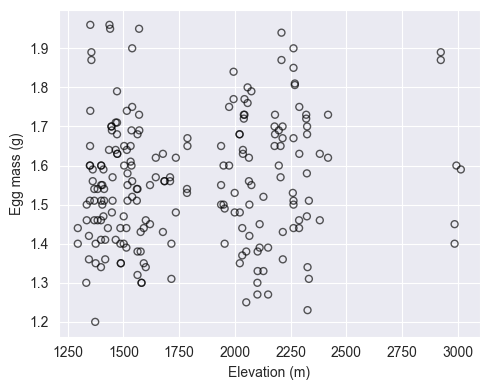

In [ ]:
label_fontsize = 9
tick_fontsize = 8
paper_facecolor = "white"
grid_color = "#E3E3E3"

fig, ax = plt.subplots(figsize=(3.1, 3.2), dpi=300, constrained_layout=True)
fig.patch.set_facecolor(paper_facecolor)
ax.set_facecolor(paper_facecolor)

ax.scatter(
    df_egg_weight_clean["Elevacion"],
    df_egg_weight_clean["Huevo_Peso_g"],
    s=18,
    alpha=0.72,
    color="#7F7F7F",
    edgecolor="black",
    linewidth=0.35,
)

ax.set_xlabel("Elevation (m)", fontsize=label_fontsize)
ax.set_ylabel("Egg mass (g)", fontsize=label_fontsize)
ax.tick_params(axis="both", labelsize=tick_fontsize)
ax.grid(True, color=grid_color, linewidth=0.6)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)

plt.show()

In [116]:
# Centre predictors
# -------------------------------------------------

mean_elev_egg_weight = df_egg_weight_clean['Elevacion'].mean()

df_egg_weight_clean['Elevacion_c_1000'] = (
    df_egg_weight_clean['Elevacion'] - mean_elev_egg_weight
) / 1600

mean_clutch_size = df_egg_weight_clean['Numero_de_Huevos'].mean()

df_egg_weight_clean['Numero_de_Huevos_c'] = (
    df_egg_weight_clean['Numero_de_Huevos'] - mean_clutch_size
)

print("Mean elevation used for centring:", mean_elev_egg_weight)
print("Mean clutch size used for centring:", mean_clutch_size)

display(
    df_egg_weight_clean[
        ['Estacion', 'ID_del_Nido', 'Especie',
         'Elevacion', 'Elevacion_c_1000',
         'Numero_de_Huevos', 'Numero_de_Huevos_c',
         'Huevo_Peso_g']
    ].head()
)

Mean elevation used for centring: 1808.6009615384614
Mean clutch size used for centring: 2.0721153846153846


,Estacion,ID_del_Nido,Especie,Elevacion,Elevacion_c_1000,Numero_de_Huevos,Numero_de_Huevos_c,Huevo_Peso_g
0,San_Pedro,01_SPR09,Myioborus_melanocephalus,1949.0,0.087749,2.0,-0.072115,1.50
1,San_Pedro,01_SPR09,Myioborus_melanocephalus,1949.0,0.087749,2.0,-0.072115,1.60
2,San_Pedro,01_SPR09a,Myioborus_miniatus,1938.0,0.080874,3.0,0.927885,1.55
3,San_Pedro,01_SPR09a,Myioborus_miniatus,1938.0,0.080874,3.0,0.927885,1.65
4,San_Pedro,01_SPR09a,Myioborus_miniatus,1938.0,0.080874,3.0,0.927885,1.50


In [117]:
# Null model
glm_egg_weight_null = smf.glm(
    formula='Huevo_Peso_g ~ 1',
    data=df_egg_weight_clean,
    family=sm.families.Gaussian()
).fit()

# Species only
glm_egg_weight_species = smf.glm(
    formula='Huevo_Peso_g ~ C(Especie)',
    data=df_egg_weight_clean,
    family=sm.families.Gaussian()
).fit()

# Elevation only
glm_egg_weight_elevation = smf.glm(
    formula='Huevo_Peso_g ~ Elevacion_c_1000',
    data=df_egg_weight_clean,
    family=sm.families.Gaussian()
).fit()

# Species + elevation
glm_egg_weight_species_elevation = smf.glm(
    formula='Huevo_Peso_g ~ C(Especie) + Elevacion_c_1000',
    data=df_egg_weight_clean,
    family=sm.families.Gaussian()
).fit()

In [118]:
aic_egg_weight = pd.DataFrame({
    "model": [
        "Null",
        "Species only",
        "Elevation only",
        "Species + elevation"
    ],
    "formula": [
        "Huevo_Peso_g ~ 1",
        "Huevo_Peso_g ~ C(Especie)",
        "Huevo_Peso_g ~ Elevacion_c_1000",
        "Huevo_Peso_g ~ C(Especie) + Elevacion_c_1000"
    ],
    "AIC": [
        glm_egg_weight_null.aic,
        glm_egg_weight_species.aic,
        glm_egg_weight_elevation.aic,
        glm_egg_weight_species_elevation.aic
    ],
    "deviance": [
        glm_egg_weight_null.deviance,
        glm_egg_weight_species.deviance,
        glm_egg_weight_elevation.deviance,
        glm_egg_weight_species_elevation.deviance
    ],
    "df_resid": [
        glm_egg_weight_null.df_resid,
        glm_egg_weight_species.df_resid,
        glm_egg_weight_elevation.df_resid,
        glm_egg_weight_species_elevation.df_resid
    ]
})

aic_egg_weight = aic_egg_weight.sort_values("AIC").copy()
aic_egg_weight["Delta_AIC"] = aic_egg_weight["AIC"] - aic_egg_weight["AIC"].min()

display(aic_egg_weight)

,model,formula,AIC,deviance,df_resid,Delta_AIC
1,Species only,Huevo_Peso_g ~ C(Especie),-168.530152,5.313173,206,0.000000
3,Species + elevation,Huevo_Peso_g ~ C(Especie) + Elevacion_c_1000,-167.102996,5.298560,205,1.427155
2,Elevation only,Huevo_Peso_g ~ Elevacion_c_1000,-166.768615,5.358361,206,1.761537
0,Null,Huevo_Peso_g ~ 1,-166.079694,5.428080,207,2.450458


In [119]:
best_model_name = aic_egg_weight.iloc[0]["model"]
best_formula = aic_egg_weight.iloc[0]["formula"]
best_aic = aic_egg_weight.iloc[0]["AIC"]

print("Best model by AIC:", best_model_name)
print("Formula:", best_formula)
print("AIC:", best_aic)

Best model by AIC: Species only
Formula: Huevo_Peso_g ~ C(Especie)
AIC: -168.53015159290297


In [120]:
print(glm_egg_weight_species.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           Huevo_Peso_g   No. Observations:                  208
Model:                            GLM   Df Residuals:                      206
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                        0.025792
Method:                          IRLS   Log-Likelihood:                 86.265
Date:                Thu, 07 May 2026   Deviance:                       5.3132
Time:                        22:26:09   Pearson chi2:                     5.31
No. Iterations:                     3   Pseudo R-squ. (CS):            0.02124
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [121]:
egg_species_means = pd.DataFrame({
    "Species": ["M. melanocephalus", "M. miniatus"],
    "estimated_egg_mass_g": [
        glm_egg_weight_species.params["Intercept"],
        glm_egg_weight_species.params["Intercept"] +
        glm_egg_weight_species.params["C(Especie)[T.Myioborus_miniatus]"]
    ]
})

egg_species_means["estimated_egg_mass_g"] = egg_species_means["estimated_egg_mass_g"].round(3)

display(egg_species_means)

,Species,estimated_egg_mass_g
0,M. melanocephalus,1.665
1,M. miniatus,1.555


In [122]:
difference = glm_egg_weight_species.params["C(Especie)[T.Myioborus_miniatus]"]

print("Difference M. miniatus - M. melanocephalus:", round(difference, 3), "g")
print("Percent difference:", round((difference / glm_egg_weight_species.params["Intercept"]) * 100, 2), "%")

Difference M. miniatus - M. melanocephalus: -0.11 g
Percent difference: -6.6 %


In [124]:
import seaborn as sns

## Final synthesis



**English**



Supplementary 1 shows that elevational and interspecific variation is expressed more strongly in nest architecture than in egg traits. Across 96 nests, the best-supported model for total nest mass included species and elevation ($AIC = 724.23$), and nest mass increased by 0.517 on the log scale for each 1000 m increase in elevation. At mean elevation, the estimated nest mass was about 14.1 g in *Myioborus melanocephalus*, 22.5 g in *M. miniatus*, and 28.8 g in *M. ornatus*. By contrast, egg traits were more conservative. In the filtered egg-mass dataset, the species-only model was the best-supported one ($AIC = -168.53$; 208 eggs in the fitted model), with an estimated mean egg mass of 1.665 g for *M. melanocephalus* and 1.555 g for *M. miniatus*. That difference of -0.110 g, or about -6.6%, is supported, but it is still smaller than the separation observed in nest mass. Egg volume and elongation also remained weak or borderline in the mixed models, which supports the broader interpretation that along this elevational system the main reproductive adjustment lies in nest construction rather than in a strong redesign of egg traits.



Read as a comparative story, the species separate most clearly through nest construction. *Myioborus melanocephalus* occupies the lighter-nest end of the gradient, *M. miniatus* is intermediate but clearly heavier, and *M. ornatus* sits at the heaviest end in the available nest-mass data. The positive elevational effect on nest mass suggests that nests at higher sites require greater structural investment, while egg dimensions, egg volume, and elongation remain under tighter constraint. In practical terms, this notebook points to nest architecture as the more flexible trait set, whereas egg traits appear relatively conservative across the same environmental background.



**Español**



El Supplementary 1 muestra que la variación interespecífica y altitudinal se expresa con más fuerza en la arquitectura del nido que en los rasgos del huevo. En 96 nidos, el modelo con mejor soporte para la masa total del nido incluyó especie y elevación ($AIC = 724.23$), y la masa del nido aumentó 0.517 en escala logarítmica por cada 1000 m de elevación. A la elevación media, la masa estimada del nido fue de aproximadamente 14.1 g en *Myioborus melanocephalus*, 22.5 g en *M. miniatus* y 28.8 g en *M. ornatus*. En cambio, los rasgos del huevo fueron más conservados. En el conjunto filtrado de masa del huevo, el modelo con mejor soporte fue el de especie solamente ($AIC = -168.53$; 208 huevos en el modelo ajustado), con una masa media estimada de 1.665 g para *M. melanocephalus* y 1.555 g para *M. miniatus*. Esa diferencia de -0.110 g, o cerca de -6.6%, está soportada, pero aun así es menor que la separación observada en la masa del nido. El volumen y la elongación del huevo también permanecieron débiles o borderline en los modelos mixtos, lo que respalda la interpretación general de que en este gradiente altitudinal el ajuste reproductivo principal está en cuánto material se invierte en el nido y no en un rediseño fuerte de los rasgos del huevo.



Leído como una historia comparativa, las especies se separan sobre todo por la construcción del nido. *Myioborus melanocephalus* ocupa el extremo de nidos más livianos, *M. miniatus* es intermedio pero claramente más pesado, y *M. ornatus* aparece en el extremo de nidos más pesados dentro de los datos disponibles de masa del nido. El efecto positivo de la elevación sobre la masa del nido sugiere que los nidos en sitios altos requieren mayor inversión estructural, mientras que las dimensiones del huevo, el volumen del huevo y la elongación permanecen bajo restricciones más fuertes. En términos prácticos, este notebook apunta a que la arquitectura del nido es el conjunto de rasgos más flexible, mientras que los rasgos del huevo parecen relativamente conservados bajo el mismo fondo ambiental.

<img src="Figures\Logos\Partners.png" width="800px">